# 02 - Feature Engineering and Exploratory Data Analysis

## Alignment Notes
- Core question: Which crash conditions and spatial-temporal patterns are associated with severe outcomes before formal modeling?
- Predicting task in this notebook: None. This notebook performs feature engineering and diagnostic EDA.
- Based on what data: Base train/test outputs from notebook 01 (`train.csv`, `test.csv`).
- Unit of analysis:
  - Crash-level rows for feature diagnostics.
  - Aggregated condition profiles (`grid_cell x weather x lighting x time_bucket`) for risk-preview analysis.
- Main process: grouped feature engineering, class/temporal/categorical/numerical/spatial EDA, and aggregation preview.
- Output artifacts:
  - `dataset/cleaned_data/train_model.csv`
  - `dataset/cleaned_data/test_model.csv`
  - `dataset/cleaned_data/aggregation_preview_top_profiles.csv`
  - EDA figures in `image/02_eda/`
- Answers for team: Defines interpretable features and evidence that motivate both crash-level and condition-level modeling in notebook 03.


In [215]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_ROOT = Path('dataset') if Path('dataset').exists() else Path('../dataset')
TRAIN_PATH = DATA_ROOT / 'cleaned_data' / 'train.csv'
TEST_PATH = DATA_ROOT / 'cleaned_data' / 'test.csv'
assert TRAIN_PATH.exists() and TEST_PATH.exists(), 'Run 01_data_preparation.ipynb first.'

IMAGE_DIR = Path('image/02_eda') if Path('image').exists() or Path('notebooks').exists() else Path('../image/02_eda')
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(filename: str, dpi: int = 180) -> Path:
    out = IMAGE_DIR / filename
    plt.savefig(out, dpi=dpi, bbox_inches='tight')
    print('Saved figure:', out.resolve())
    return out


train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
for frame in [train_raw, test_raw]:
    frame['CRASH_DATE'] = pd.to_datetime(frame['CRASH_DATE'], errors='coerce')

print('Train base shape:', train_raw.shape)
print('Test base shape:', test_raw.shape)
print('Train severe rate:', round(train_raw['is_severe'].mean() * 100, 2), '%')
print('Test severe rate:', round(test_raw['is_severe'].mean() * 100, 2), '%')
print('Image output folder:', IMAGE_DIR.resolve())

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

Train base shape: (246221, 21)
Test base shape: (82274, 21)
Train severe rate: 1.65 %
Test severe rate: 1.51 %
Image output folder: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda


## 0) Feature engineering for modeling


### Group A: Incident-context binary features

Justification: intersection crashes, hit-and-run events, and self-reported records, and also some traffic way type  are operationally meaningful signals for severity risk.


In [216]:
def normalize_text(series: pd.Series) -> pd.Series:
    return series.fillna('UNKNOWN').astype(str).str.upper().str.strip().replace({'': 'UNKNOWN'})

df_fe = pd.concat([
    train_raw.assign(_split='train'),
    test_raw.assign(_split='test')
], ignore_index=True)

for col in ['INTERSECTION_RELATED_I', 'HIT_AND_RUN_I']:
    if col in df_fe.columns:
        df_fe[col] = (
            df_fe[col]
            .fillna('N')
            .astype(str)
            .str.strip()
            .str.upper()
            .replace({'': 'N'})
        )

if 'INTERSECTION_RELATED_I' in df_fe.columns:
    df_fe['is_intersection'] = (df_fe['INTERSECTION_RELATED_I'] == 'Y').astype(int)
else:
    df_fe['is_intersection'] = 0

if 'HIT_AND_RUN_I' in df_fe.columns:
    df_fe['is_hit_and_run'] = (df_fe['HIT_AND_RUN_I'] == 'Y').astype(int)
else:
    df_fe['is_hit_and_run'] = 0

if 'is_self_reported' not in df_fe.columns and 'REPORT_TYPE' in df_fe.columns:
    df_fe['is_self_reported'] = df_fe['REPORT_TYPE'].astype(str).str.upper().str.contains('NOT ON SCENE').astype(int)

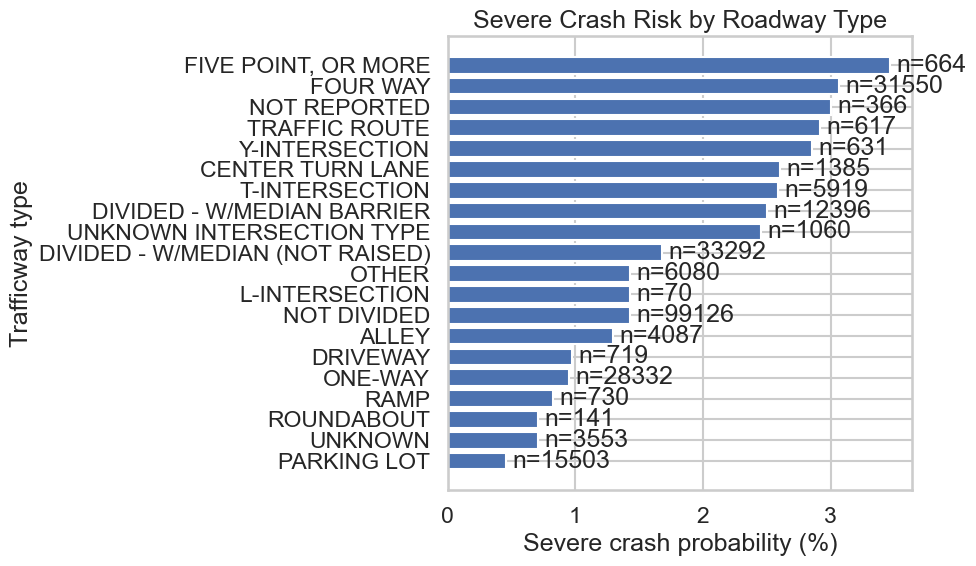

In [217]:
# Severe crash risk by roadway structure

road_env = (
    train_raw.groupby('TRAFFICWAY_TYPE', as_index=False)
            .agg(
                crash_count=('is_severe','size'),
                severe_count=('is_severe','sum'),
                severe_rate=('is_severe','mean')
            )
)

road_env = road_env[road_env['crash_count'] >= 50]   # remove unstable groups
road_env['severe_rate_pct'] = road_env['severe_rate'] * 100

road_env = road_env.sort_values('severe_rate_pct')

plt.figure(figsize=(10,6))

bars = plt.barh(
    road_env['TRAFFICWAY_TYPE'],
    road_env['severe_rate_pct'],
    color='#4C72B0'
)

plt.xlabel('Severe crash probability (%)')
plt.ylabel('Trafficway type')
plt.title('Severe Crash Risk by Roadway Type')

for bar, n in zip(bars, road_env['crash_count']):
    plt.text(
        bar.get_width()+0.05,
        bar.get_y()+bar.get_height()/2,
        f'n={n}',
        va='center'
    )

plt.tight_layout()
plt.show()

In [218]:
# Binary trafficway indicators for EDA interpretation
if 'TRAFFICWAY_TYPE' in df_fe.columns:
    t = normalize_text(df_fe['TRAFFICWAY_TYPE'])
    df_fe['is_four_way'] = (t == 'FOUR WAY').astype(int)
    df_fe['is_five_point'] = t.str.contains('FIVE POINT', na=False).astype(int)
    df_fe['is_y_intersection'] = t.str.contains('Y-INTERSECTION', na=False).astype(int)
    df_fe['is_t_intersection'] = t.str.contains('T-INTERSECTION', na=False).astype(int)
    df_fe['is_divided_road'] = t.str.contains('DIVIDED', na=False).astype(int)
else:
    df_fe['is_four_way'] = 0
    df_fe['is_five_point'] = 0
    df_fe['is_y_intersection'] = 0
    df_fe['is_t_intersection'] = 0
    df_fe['is_divided_road'] = 0


### Group B: Temporal risk features

Justification: Time patterns strongly influence crash severity. Time windows such as nighttime, weekend, and rush hour are actionable for policy targeting and operational deployment. Chicago crash severity may differ in winter vs summer.


In [219]:
for col in ['CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH']:
    if col in df_fe.columns:
        df_fe[col] = pd.to_numeric(df_fe[col], errors='coerce')

if 'CRASH_HOUR' in df_fe.columns:
    df_fe['is_night'] = df_fe['CRASH_HOUR'].isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
    df_fe['is_rush_hour'] = df_fe['CRASH_HOUR'].isin([7, 8, 9, 16, 17, 18]).astype(int)
else:
    df_fe['is_night'] = 0
    df_fe['is_rush_hour'] = 0

if 'CRASH_DAY_OF_WEEK' in df_fe.columns:
    df_fe['is_weekend'] = df_fe['CRASH_DAY_OF_WEEK'].isin([1, 7]).astype(int)
else:
    df_fe['is_weekend'] = 0

# Season 
def get_season(month):
    if pd.isna(month):
        return 'UNKNOWN'
    month = int(month)
    if month in [12, 1, 2]:
        return 'WINTER'
    elif month in [3, 4, 5]:
        return 'SPRING'
    elif month in [6, 7, 8]:
        return 'SUMMER'
    elif month in [9, 10, 11]:
        return 'FALL'
    return 'UNKNOWN'

df_fe['season'] = df_fe['CRASH_MONTH'].apply(get_season)

In [220]:
# Weather and visibility signals
if 'WEATHER_CONDITION' in df_fe.columns:
    weather = normalize_text(df_fe['WEATHER_CONDITION'])

    weather_standardized = np.select(
        [
            weather.str.contains('BLOWING SNOW'),
            weather.str.contains('CLEAR'),
            weather.str.contains('CLOUD'),
            weather.str.contains('FOG|SMOKE|HAZE'),
            weather.str.contains('FREEZING RAIN|FREEZING DRIZZLE'),
            weather.str.contains('RAIN|DRIZZLE'),
            weather.str.contains('SLEET|HAIL'),
            weather.str.contains('SNOW'),
            weather.eq('UNKNOWN')
        ],
        [
            'BLOWING SNOW', 'CLEAR', 'CLOUDY/OVERCAST', 'FOG/SMOKE/HAZE',
            'FREEZING RAIN/DRIZZLE', 'RAIN', 'SLEET/HAIL', 'SNOW', 'UNKNOWN'
        ],
        default='OTHER'
    )
    df_fe['WEATHER_CONDITION'] = weather_standardized

    df_fe['weather_bucket'] = np.select(
        [
            weather.str.contains('CLEAR'),
            weather.str.contains('CLOUD'),
            weather.str.contains('RAIN|DRIZZLE'),
            weather.str.contains('SNOW|SLEET|ICE|FREEZING|BLOWING SNOW'),
            weather.str.contains('FOG|SMOKE|HAZE'),
            weather.eq('UNKNOWN')
        ],
        ['CLEAR', 'CLOUDY', 'RAIN', 'SNOW_ICE', 'LOW_VISIBILITY', 'UNKNOWN'],
        default='OTHER'
    )

    df_fe['adverse_weather'] = df_fe['weather_bucket'].isin(
        ['RAIN', 'SNOW_ICE', 'LOW_VISIBILITY']
    ).astype(int)
else:
    df_fe['WEATHER_CONDITION'] = 'UNKNOWN'
    df_fe['weather_bucket'] = 'UNKNOWN'
    df_fe['adverse_weather'] = 0

if 'LIGHTING_CONDITION' in df_fe.columns:
    lighting = normalize_text(df_fe['LIGHTING_CONDITION'])
    df_fe['is_dark'] = lighting.isin([
        'DARKNESS', 'DARKNESS, LIGHTED ROAD', 'DAWN', 'DUSK'
    ]).astype(int)
else:
    df_fe['is_dark'] = 0

df_fe['low_visibility'] = (
    (df_fe['adverse_weather'] == 1) |
    (df_fe['is_dark'] == 1)
).astype(int)

if 'ROADWAY_SURFACE_COND' in df_fe.columns:
    surface = normalize_text(df_fe['ROADWAY_SURFACE_COND'])
    df_fe['slippery_surface'] = surface.isin([
        'WET', 'SNOW OR SLUSH', 'ICE', 'SAND, MUD, DIRT'
    ]).astype(int)
else:
    df_fe['slippery_surface'] = 0

if 'POSTED_SPEED_LIMIT' in df_fe.columns:
    speed = pd.to_numeric(df_fe['POSTED_SPEED_LIMIT'], errors='coerce')
    df_fe['speed_tier'] = pd.cut(
        speed,
        bins=[-np.inf, 20, 30, 40, np.inf],
        labels=['LOW', 'MEDIUM', 'HIGH', 'VERY_HIGH']
    ).astype(str)
    df_fe['high_speed_area'] = (speed >= 35).astype(int)
else:
    df_fe['speed_tier'] = 'UNKNOWN'
    df_fe['high_speed_area'] = 0

df_fe['night_weekend'] = (
    (df_fe['is_night'] == 1) &
    (df_fe['is_weekend'] == 1)
).astype(int)

df_fe['dark_high_speed'] = (
    (df_fe['is_dark'] == 1) &
    (df_fe['high_speed_area'] == 1)
).astype(int)

df_fe['low_visibility_high_speed'] = (
    (df_fe['low_visibility'] == 1) &
    (df_fe['high_speed_area'] == 1)
).astype(int)


### Group C: Grouped high-cardinality features

Justification: grouping high-cardinality categories reduces sparsity and variance, while preserving useful semantic structure for model stability.


In [221]:
if 'TRAFFIC_CONTROL_DEVICE' in df_fe.columns:
    tcd = normalize_text(df_fe['TRAFFIC_CONTROL_DEVICE'])
    df_fe['traffic_control_group'] = np.select(
        [
            tcd.str.contains('SIGNAL'),
            tcd.str.contains('STOP'),
            tcd.str.contains('NO CONTROLS|NONE|UNKNOWN'),
        ],
        ['SIGNAL', 'STOP_SIGN', 'NO_CONTROLS_OR_UNKNOWN'],
        default='OTHER',
    )

if 'FIRST_CRASH_TYPE' in df_fe.columns:
    fct = normalize_text(df_fe['FIRST_CRASH_TYPE'])
    df_fe['first_crash_group'] = np.select(
        [
            fct.eq('ANGLE'),
            fct.eq('FIXED OBJECT'),
            fct.eq('PARKED MOTOR VEHICLE'),
            fct.eq('PEDESTRIAN'),
            fct.eq('REAR END'),
            fct.eq('SIDESWIPE SAME DIRECTION'),
            fct.eq('TURNING'),
        ],
        [
            'ANGLE', 'FIXED OBJECT', 'PARKED MOTOR VEHICLE', 'PEDESTRIAN',
            'REAR END', 'SIDESWIPE SAME DIRECTION', 'TURNING'
        ],
        default='OTHER'
    )

    df_fe['crash_type_risk_group'] = np.select(
        [
            fct.str.contains('PEDESTRIAN|PEDALCYCLE'),
            fct.str.contains('HEAD ON'),
            fct.str.contains('ANGLE'),
            fct.str.contains('REAR END'),
            fct.str.contains('FIXED OBJECT'),
            fct.str.contains('SIDESWIPE'),
            fct.str.contains('TURNING'),
        ],
        [
            'PEDESTRIAN_CYCLIST', 'HEAD_ON', 'ANGLE', 'REAR_END',
            'FIXED_OBJECT', 'SIDESWIPE', 'TURNING'
        ],
        default='OTHER'
    )

if 'PRIM_CONTRIBUTORY_CAUSE' in df_fe.columns:
    cause = normalize_text(df_fe['PRIM_CONTRIBUTORY_CAUSE'])
    priority_causes = {
        'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE',
        'FAILING TO REDUCE SPEED TO AVOID CRASH',
        'FAILING TO YIELD RIGHT-OF-WAY',
        'FOLLOWING TOO CLOSELY',
        'IMPROPER BACKING',
        'IMPROPER LANE USAGE',
        'IMPROPER OVERTAKING/PASSING',
        'IMPROPER TURNING/NO SIGNAL',
        'NOT APPLICABLE',
        'UNABLE TO DETERMINE',
    }
    df_fe['prim_cause_group'] = np.where(cause.isin(priority_causes), cause, 'OTHER')

# EDA helper copies for interpretable plots
for col in [
    'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'ROADWAY_SURFACE_COND',
    'traffic_control_group', 'crash_type_risk_group'
]:
    if col in df_fe.columns:
        df_fe[f'eda_{col.lower()}'] = df_fe[col].astype(str)

def trafficway_structure_label(row):
    if row['is_five_point'] == 1:
        return 'FIVE POINT OR MORE'
    if row['is_four_way'] == 1:
        return 'FOUR WAY'
    if row['is_y_intersection'] == 1:
        return 'Y-INTERSECTION'
    if row['is_t_intersection'] == 1:
        return 'T-INTERSECTION'
    if row['is_divided_road'] == 1:
        return 'DIVIDED ROAD'
    return 'OTHER'

df_fe['eda_trafficway_structure'] = df_fe.apply(trafficway_structure_label, axis=1)


### Group D: One-hot encoding and compact model matrix

Justification: one-hot encoding is appropriate for low-cardinality categories. Ultra-rare dummy columns are removed to reduce noise and keep exported CSV sizes practical.


In [222]:
one_hot_cols = [
    'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'ROADWAY_SURFACE_COND',
    'ALIGNMENT', 'DEVICE_CONDITION', 'ROAD_DEFECT', 'DAMAGE', 'TRAFFICWAY_TYPE',
    'traffic_control_group', 'first_crash_group', 'prim_cause_group'
]

one_hot_cols = [c for c in one_hot_cols if c in df_fe.columns]

model_df = pd.get_dummies(df_fe, columns=one_hot_cols, prefix_sep='__', dtype=int)

# Remove identifier/text fields from model matrix
# Keep Diyouva-compatible numeric fields and raw columns only when they are encoded above.
drop_for_model = [
    'CRASH_RECORD_ID', 'REPORT_TYPE', 'INTERSECTION_RELATED_I', 'HIT_AND_RUN_I',
    'TRAFFIC_CONTROL_DEVICE', 'FIRST_CRASH_TYPE', 'PRIM_CONTRIBUTORY_CAUSE',
    'weather_bucket', 'speed_tier',
    'crash_type_risk_group',
    'is_four_way', 'is_five_point', 'is_y_intersection', 'is_t_intersection', 'is_divided_road',
    'adverse_weather', 'is_dark', 'low_visibility', 'slippery_surface',
    'high_speed_area', 'night_weekend', 'dark_high_speed', 'low_visibility_high_speed',
    'season'
]

# Remove EDA-only helper copies from modeling matrix
eda_helper_cols = [col for col in model_df.columns if col.startswith('eda_')]
if eda_helper_cols:
    model_df = model_df.drop(columns=eda_helper_cols)
for col in drop_for_model:
    if col in model_df.columns:
        model_df = model_df.drop(columns=col)

for col in model_df.columns:
    if col in ['CRASH_DATE', '_split']:
        continue
    if model_df[col].dtype == 'O':
        model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

for col in model_df.columns:
    if col in ['CRASH_DATE', '_split']:
        continue
    if pd.api.types.is_numeric_dtype(model_df[col]) and model_df[col].isna().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

# Align to Diyouva's intended feature contract while keeping notebook execution reproducible.
required_feature_cols = [
    "POSTED_SPEED_LIMIT",
    "NUM_UNITS",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "LATITUDE",
    "LONGITUDE",
    "is_self_reported",
    "is_intersection",
    "is_hit_and_run",
    "is_night",
    "is_rush_hour",
    "is_weekend",
    "WEATHER_CONDITION__BLOWING SNOW",
    "WEATHER_CONDITION__CLEAR",
    "WEATHER_CONDITION__CLOUDY/OVERCAST",
    "WEATHER_CONDITION__FOG/SMOKE/HAZE",
    "WEATHER_CONDITION__FREEZING RAIN/DRIZZLE",
    "WEATHER_CONDITION__OTHER",
    "WEATHER_CONDITION__RAIN",
    "WEATHER_CONDITION__SLEET/HAIL",
    "WEATHER_CONDITION__SNOW",
    "WEATHER_CONDITION__UNKNOWN",
    "LIGHTING_CONDITION__DARKNESS",
    "LIGHTING_CONDITION__DARKNESS, LIGHTED ROAD",
    "LIGHTING_CONDITION__DAWN",
    "LIGHTING_CONDITION__DAYLIGHT",
    "LIGHTING_CONDITION__DUSK",
    "LIGHTING_CONDITION__UNKNOWN",
    "ROADWAY_SURFACE_COND__DRY",
    "ROADWAY_SURFACE_COND__ICE",
    "ROADWAY_SURFACE_COND__OTHER",
    "ROADWAY_SURFACE_COND__SNOW OR SLUSH",
    "ROADWAY_SURFACE_COND__UNKNOWN",
    "ROADWAY_SURFACE_COND__WET",
    "ALIGNMENT__CURVE ON GRADE",
    "ALIGNMENT__CURVE, LEVEL",
    "ALIGNMENT__STRAIGHT AND LEVEL",
    "ALIGNMENT__STRAIGHT ON GRADE",
    "ALIGNMENT__STRAIGHT ON HILLCREST",
    "DEVICE_CONDITION__FUNCTIONING IMPROPERLY",
    "DEVICE_CONDITION__FUNCTIONING PROPERLY",
    "DEVICE_CONDITION__NO CONTROLS",
    "DEVICE_CONDITION__NOT FUNCTIONING",
    "DEVICE_CONDITION__OTHER",
    "DEVICE_CONDITION__UNKNOWN",
    "ROAD_DEFECT__DEBRIS ON ROADWAY",
    "ROAD_DEFECT__NO DEFECTS",
    "ROAD_DEFECT__OTHER",
    "ROAD_DEFECT__RUT, HOLES",
    "ROAD_DEFECT__SHOULDER DEFECT",
    "ROAD_DEFECT__UNKNOWN",
    "ROAD_DEFECT__WORN SURFACE",
    "DAMAGE__$500 OR LESS",
    "DAMAGE__$501 - $1,500",
    "DAMAGE__OVER $1,500",
    "TRAFFICWAY_TYPE__ALLEY",
    "TRAFFICWAY_TYPE__CENTER TURN LANE",
    "TRAFFICWAY_TYPE__DIVIDED - W/MEDIAN (NOT RAISED)",
    "TRAFFICWAY_TYPE__DIVIDED - W/MEDIAN BARRIER",
    "TRAFFICWAY_TYPE__DRIVEWAY",
    "TRAFFICWAY_TYPE__FIVE POINT, OR MORE",
    "TRAFFICWAY_TYPE__FOUR WAY",
    "TRAFFICWAY_TYPE__NOT DIVIDED",
    "TRAFFICWAY_TYPE__NOT REPORTED",
    "TRAFFICWAY_TYPE__ONE-WAY",
    "TRAFFICWAY_TYPE__OTHER",
    "TRAFFICWAY_TYPE__PARKING LOT",
    "TRAFFICWAY_TYPE__RAMP",
    "TRAFFICWAY_TYPE__ROUNDABOUT",
    "TRAFFICWAY_TYPE__T-INTERSECTION",
    "TRAFFICWAY_TYPE__TRAFFIC ROUTE",
    "TRAFFICWAY_TYPE__UNKNOWN",
    "TRAFFICWAY_TYPE__UNKNOWN INTERSECTION TYPE",
    "TRAFFICWAY_TYPE__Y-INTERSECTION",
    "traffic_control_group__NO_CONTROLS_OR_UNKNOWN",
    "traffic_control_group__OTHER",
    "traffic_control_group__SIGNAL",
    "traffic_control_group__STOP_SIGN",
    "first_crash_group__ANGLE",
    "first_crash_group__FIXED OBJECT",
    "first_crash_group__OTHER",
    "first_crash_group__PARKED MOTOR VEHICLE",
    "first_crash_group__PEDESTRIAN",
    "first_crash_group__REAR END",
    "first_crash_group__SIDESWIPE SAME DIRECTION",
    "first_crash_group__TURNING",
    "prim_cause_group__DRIVING SKILLS/KNOWLEDGE/EXPERIENCE",
    "prim_cause_group__FAILING TO REDUCE SPEED TO AVOID CRASH",
    "prim_cause_group__FAILING TO YIELD RIGHT-OF-WAY",
    "prim_cause_group__FOLLOWING TOO CLOSELY",
    "prim_cause_group__IMPROPER BACKING",
    "prim_cause_group__IMPROPER LANE USAGE",
    "prim_cause_group__IMPROPER OVERTAKING/PASSING",
    "prim_cause_group__IMPROPER TURNING/NO SIGNAL",
    "prim_cause_group__NOT APPLICABLE",
    "prim_cause_group__OTHER",
    "prim_cause_group__UNABLE TO DETERMINE"
]

for col in required_feature_cols:
    if col not in model_df.columns:
        model_df[col] = 0

# Remove columns outside the Diyouva contract except the target/date/split contract fields.
keep_cols = set(required_feature_cols) | {'is_severe', 'CRASH_DATE', '_split'}
extra_cols = [c for c in model_df.columns if c not in keep_cols]
if extra_cols:
    model_df = model_df.drop(columns=extra_cols)

train_model = model_df[model_df['_split'] == 'train'].drop(columns=['_split']).copy()
test_model = model_df[model_df['_split'] == 'test'].drop(columns=['_split']).copy()

feature_cols = required_feature_cols.copy()

OUT_DIR = DATA_ROOT / 'cleaned_data'
train_model_path = OUT_DIR / 'train_model.csv'
test_model_path = OUT_DIR / 'test_model.csv'
feature_meta_path = OUT_DIR / 'feature_columns.json'

train_model.to_csv(train_model_path, index=False)
test_model.to_csv(test_model_path, index=False)
feature_meta_path.write_text(json.dumps({
    'feature_cols': feature_cols,
    'target': 'is_severe',
    'date_col': 'CRASH_DATE',
    'model_train_file': 'train_model.csv',
    'model_test_file': 'test_model.csv'
}, indent=2))

for p in [train_model_path, test_model_path]:
    print(f"{p.name}: {p.stat().st_size / (1024 * 1024):.2f} MB")

print('Model feature count:', len(feature_cols))


train_model.csv: 58.88 MB
test_model.csv: 19.68 MB
Model feature count: 101
Dropped ultra-rare dummy cols: 5


## 1) Target distribution


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/01_target_distribution.png


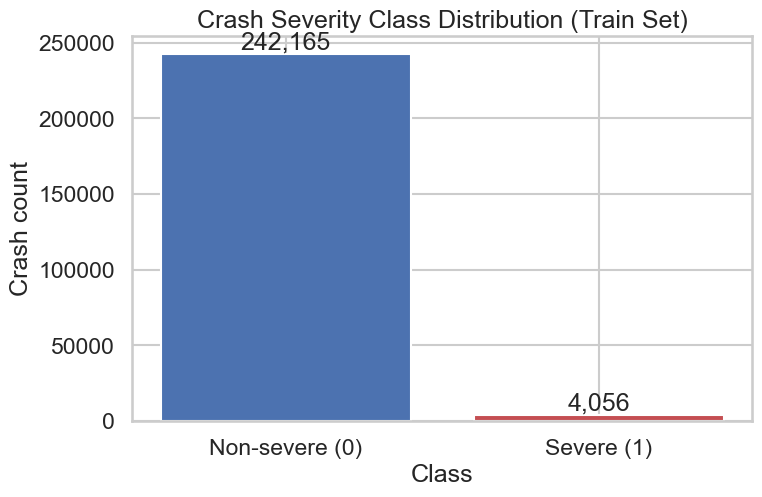

Class percentages:
is_severe
0    98.35
1     1.65
Name: count, dtype: float64


In [223]:
target_counts = train_raw['is_severe'].value_counts().sort_index()
target_pct = (target_counts / target_counts.sum() * 100).round(2)

plot_df = pd.DataFrame({
    'label': ['Non-severe (0)', 'Severe (1)'],
    'count': [target_counts.get(0, 0), target_counts.get(1, 0)],
})

plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df['label'], plot_df['count'], color=['#4C72B0', '#C44E52'])
plt.title('Crash Severity Class Distribution (Train Set)')
plt.xlabel('Class')
plt.ylabel('Crash count')
for bar, count in zip(bars, plot_df['count']):
    plt.text(bar.get_x() + bar.get_width() / 2, count, f'{int(count):,}', ha='center', va='bottom')
save_fig('01_target_distribution.png')
plt.show()

print('Class percentages:')
print(target_pct)


Interpretation:
- The severe class is a small minority, so imbalance-aware evaluation is necessary.
- In downstream modeling, prioritize recall-sensitive diagnostics alongside precision.


## 2) Temporal patterns


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/02_monthly_crash_and_severity.png


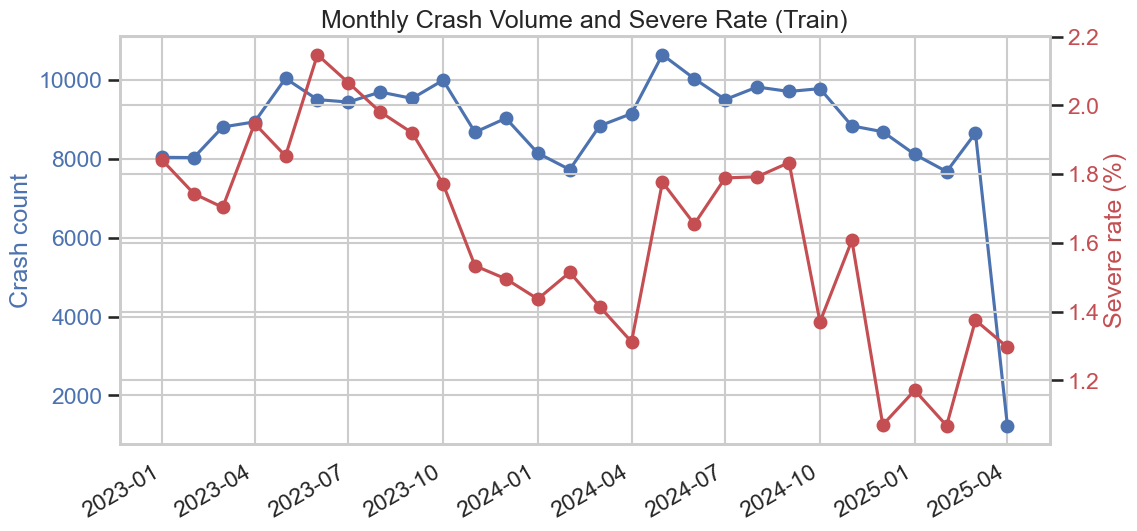

In [224]:
monthly = (
    train_raw.assign(month=train_raw['CRASH_DATE'].dt.to_period('M').dt.to_timestamp())
             .groupby('month', as_index=False)
             .agg(crash_count=('is_severe', 'size'), severe_rate=('is_severe', 'mean'))
)
monthly['severe_rate_pct'] = monthly['severe_rate'] * 100

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(monthly['month'], monthly['crash_count'], color='#4C72B0', marker='o')
ax1.set_ylabel('Crash count', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_title('Monthly Crash Volume and Severe Rate (Train)')

ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['severe_rate_pct'], color='#C44E52', marker='o')
ax2.set_ylabel('Severe rate (%)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

fig.autofmt_xdate()
save_fig('02_monthly_crash_and_severity.png')
plt.show()


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/03_severe_rate_hour_day.png


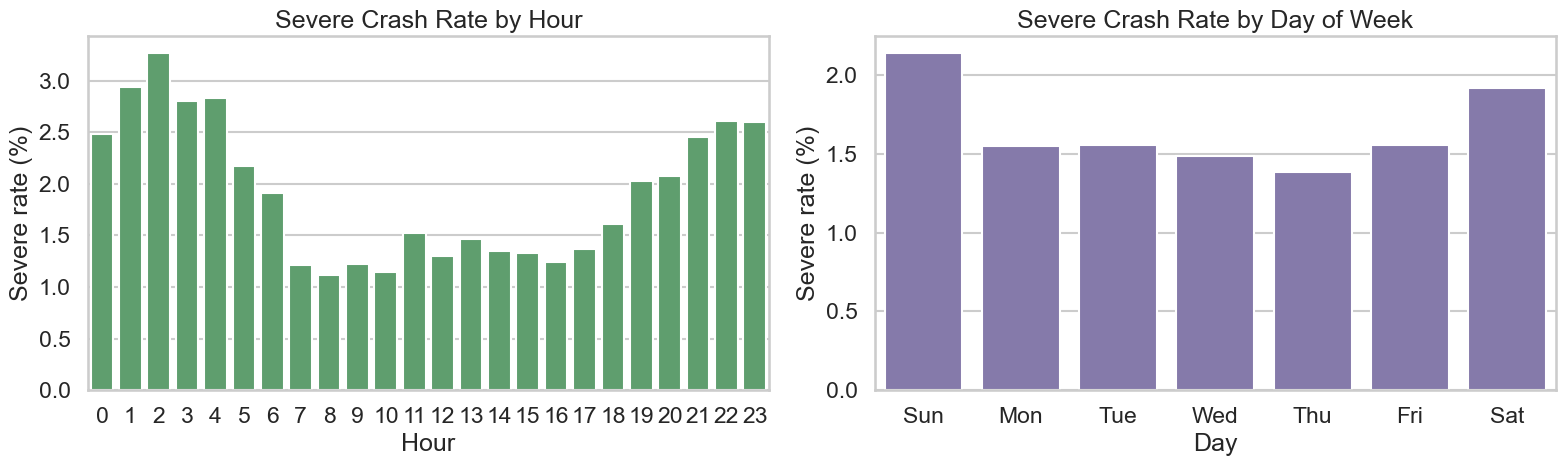

In [225]:
hourly = train_raw.groupby('CRASH_HOUR', as_index=False)['is_severe'].mean()
hourly['severe_rate_pct'] = hourly['is_severe'] * 100

dow = train_raw.groupby('CRASH_DAY_OF_WEEK', as_index=False)['is_severe'].mean()
dow['severe_rate_pct'] = dow['is_severe'] * 100
day_map = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
dow['day_name'] = dow['CRASH_DAY_OF_WEEK'].map(day_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=hourly, x='CRASH_HOUR', y='severe_rate_pct', color='#55A868', ax=axes[0])
axes[0].set_title('Severe Crash Rate by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Severe rate (%)')

sns.barplot(data=dow, x='day_name', y='severe_rate_pct', color='#8172B2', ax=axes[1], order=['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'])
axes[1].set_title('Severe Crash Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Severe rate (%)')

plt.tight_layout()
save_fig('03_severe_rate_hour_day.png')
plt.show()


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/04_hour_day_heatmap.png


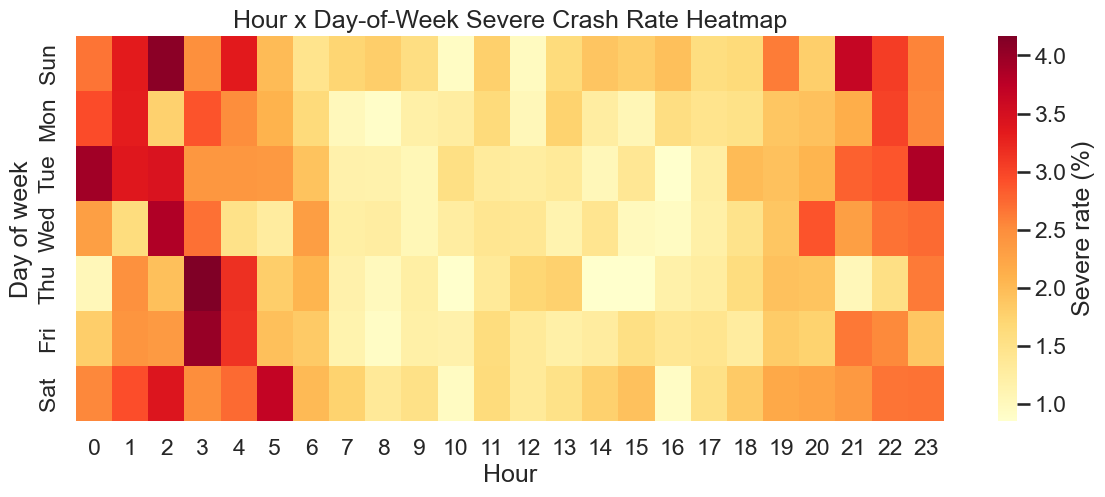

In [226]:
heat = (
    train_raw.pivot_table(index='CRASH_DAY_OF_WEEK', columns='CRASH_HOUR', values='is_severe', aggfunc='mean') * 100
)
heat = heat.reindex(index=[1, 2, 3, 4, 5, 6, 7])
heat.index = [day_map.get(i, str(i)) for i in heat.index]

plt.figure(figsize=(14, 5))
sns.heatmap(heat, cmap='YlOrRd', cbar_kws={'label': 'Severe rate (%)'})
plt.title('Hour x Day-of-Week Severe Crash Rate Heatmap')
plt.xlabel('Hour')
plt.ylabel('Day of week')
save_fig('04_hour_day_heatmap.png')
plt.show()


In [227]:
top_hours = hourly.nlargest(3, 'severe_rate_pct')[['CRASH_HOUR', 'severe_rate_pct']]
top_days = dow.nlargest(3, 'severe_rate_pct')[['day_name', 'severe_rate_pct']]
top_months = monthly.nlargest(3, 'severe_rate_pct')[['month', 'severe_rate_pct']]

print('Temporal hotspot summary:')
print('Top 3 hours by severe rate (%)')
print(top_hours.to_string(index=False))
print('\nTop 3 days by severe rate (%)')
print(top_days.to_string(index=False))
print('\nTop 3 months by severe rate (%)')
print(top_months.to_string(index=False))


Temporal hotspot summary:
Top 3 hours by severe rate (%)
 CRASH_HOUR  severe_rate_pct
          2         3.265710
          1         2.933884
          4         2.829867

Top 3 days by severe rate (%)
day_name  severe_rate_pct
     Sun         2.140419
     Sat         1.920694
     Tue         1.559332

Top 3 months by severe rate (%)
     month  severe_rate_pct
2023-06-01         2.147368
2023-07-01         2.066116
2023-08-01         1.981015


## 3) Categorical features


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/08_cat_weather_condition.png


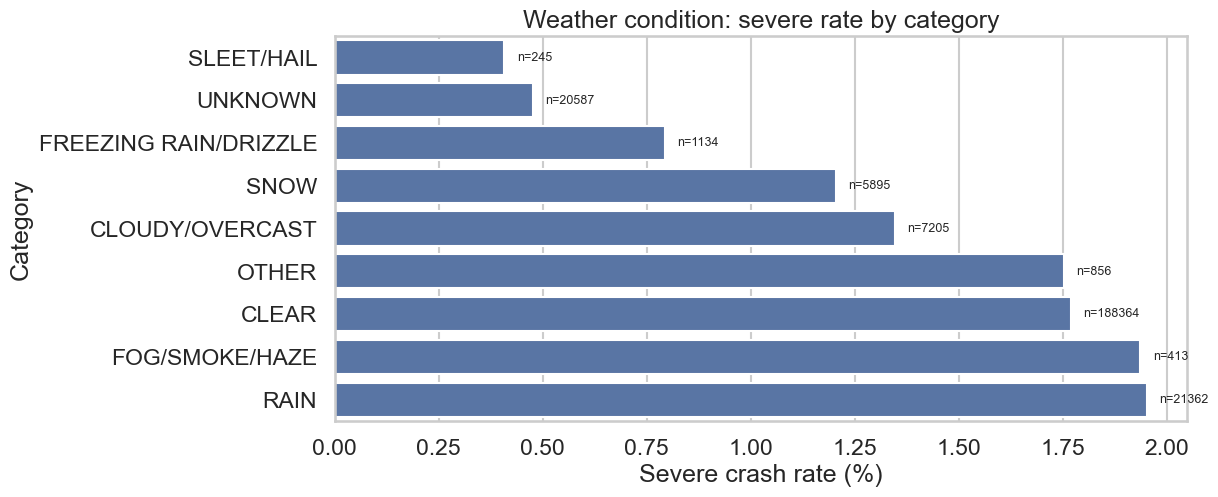

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/09_cat_lighting_condition.png


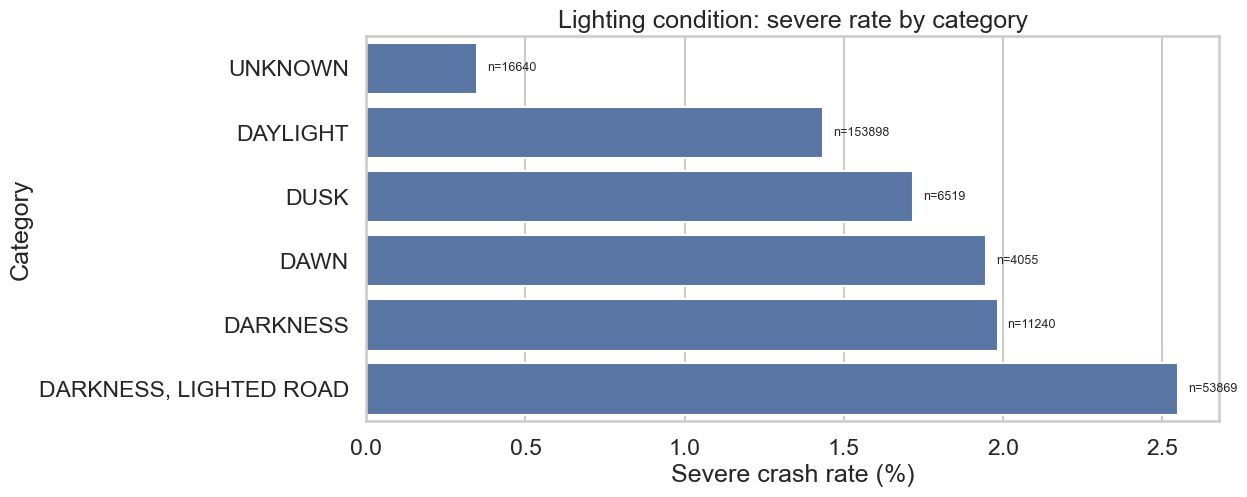

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/10_cat_roadway_surface.png


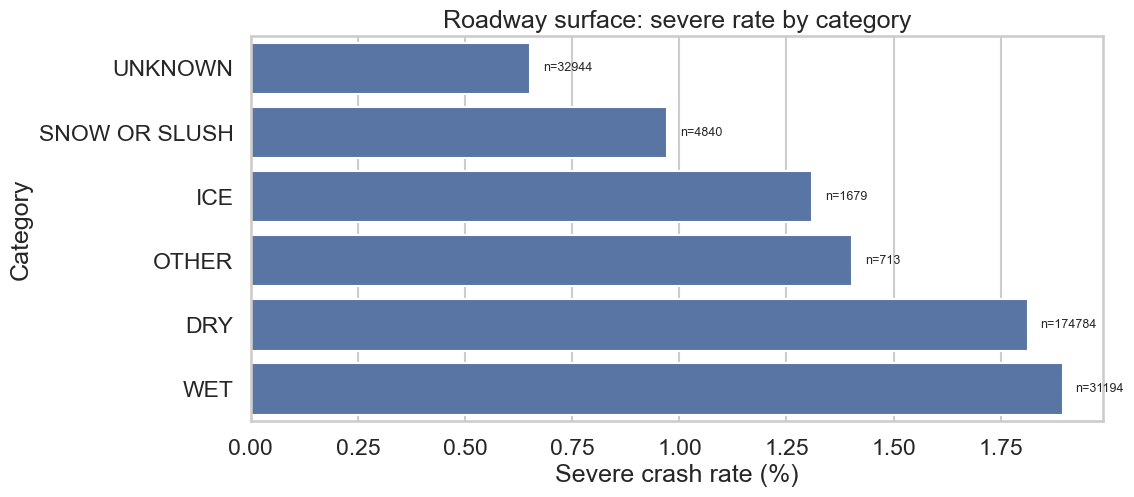

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/11_cat_crash_type_risk_group.png


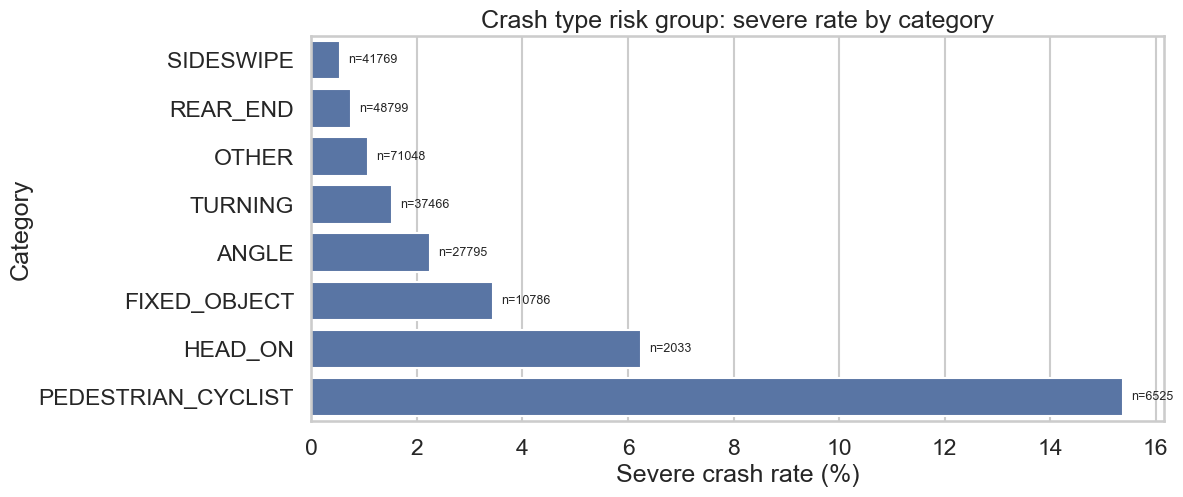

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/12_cat_traffic_control.png


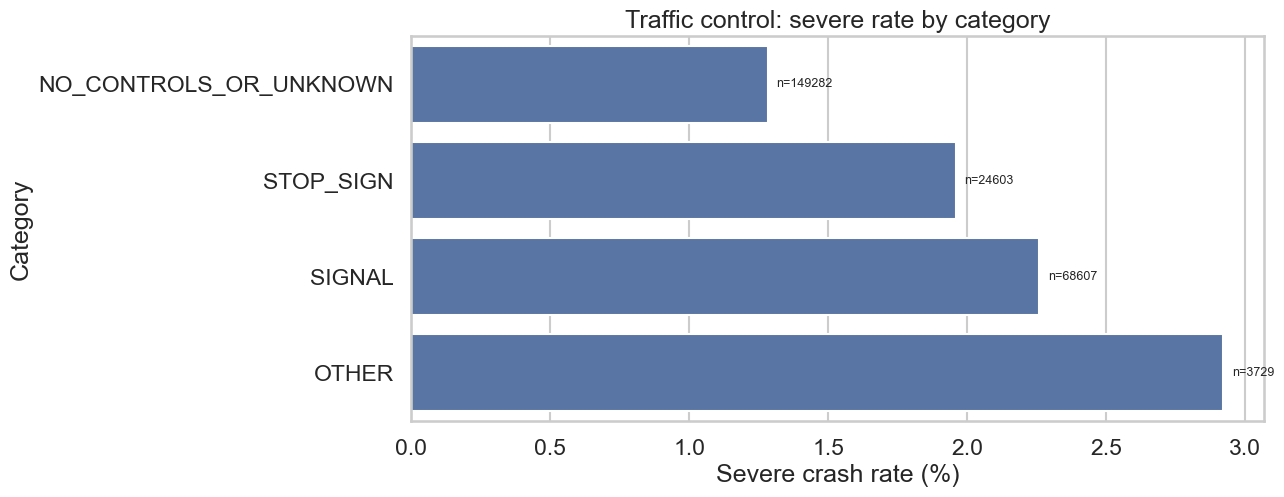

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/13_cat_trafficway_structure.png


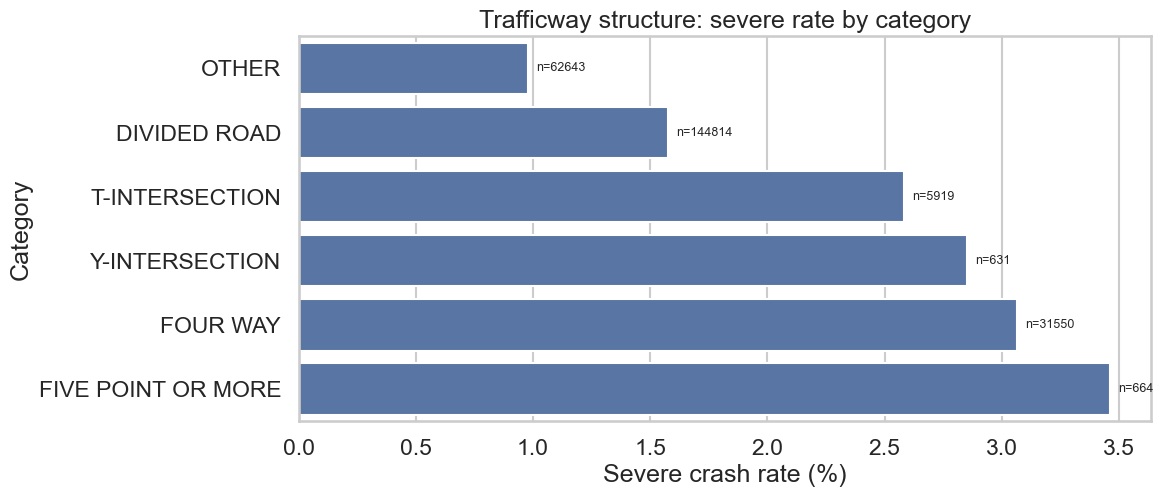

Categorical highlights:
- Weather condition: RAIN (1.95%, n=21362)
- Lighting condition: DARKNESS, LIGHTED ROAD (2.55%, n=53869)
- Roadway surface: WET (1.89%, n=31194)
- Crash type risk group: PEDESTRIAN_CYCLIST (15.39%, n=6525)
- Traffic control: OTHER (2.92%, n=3729)
- Trafficway structure: FIVE POINT OR MORE (3.46%, n=664)


In [228]:
cat_specs = [
    ('Weather condition', ['eda_weather_condition', 'WEATHER_CONDITION'], '08_cat_weather_condition.png'),
    ('Lighting condition', ['eda_lighting_condition', 'LIGHTING_CONDITION'], '09_cat_lighting_condition.png'),
    ('Roadway surface', ['eda_roadway_surface_cond', 'ROADWAY_SURFACE_COND'], '10_cat_roadway_surface.png'),
    ('Crash type risk group', ['eda_crash_type_risk_group', 'crash_type_risk_group', 'FIRST_CRASH_TYPE'], '11_cat_crash_type_risk_group.png'),
    ('Traffic control', ['eda_traffic_control_group', 'traffic_control_group', 'TRAFFIC_CONTROL_DEVICE'], '12_cat_traffic_control.png'),
    ('Trafficway structure', ['eda_trafficway_structure'], '13_cat_trafficway_structure.png')
]

train_fe = df_fe[df_fe['_split'] == 'train'].copy()


def resolve_column(candidates):
    for c in candidates:
        if c in train_fe.columns:
            return c
    return None


def severe_rate_by_category(frame, col, min_count=200, top_n=12):
    tmp = frame[[col, 'is_severe']].copy()
    tmp[col] = tmp[col].astype(str).str.strip().replace({'': 'UNKNOWN'}).fillna('UNKNOWN')
    stats = tmp.groupby(col)['is_severe'].agg(severe_rate='mean', n='size').reset_index()
    filtered = stats[stats['n'] >= min_count].copy()
    if filtered.empty:
        filtered = stats
    filtered['rate_pct'] = filtered['severe_rate'] * 100
    return filtered.sort_values(['rate_pct', 'n'], ascending=[False, False]).head(top_n)


def plot_category_rates(stats, col, title, filename):
    plot_df = stats.sort_values(['rate_pct', 'n'], ascending=[True, True]).reset_index(drop=True)
    plt.figure(figsize=(11, max(5, len(plot_df) * 0.42)))
    ax = sns.barplot(data=plot_df, x='rate_pct', y=col, color='#4C72B0')
    ax.set_title(title)
    ax.set_xlabel('Severe crash rate (%)')
    ax.set_ylabel('Category')
    m = plot_df['rate_pct'].max() if len(plot_df) else 0
    for i, row in plot_df.iterrows():
        ax.text(row['rate_pct'] + max(0.03, m * 0.01), i, f"n={int(row['n'])}", va='center', fontsize=9)
    save_fig(filename)
    plt.show()


cat_highlights = {}
for title, candidates, filename in cat_specs:
    col = resolve_column(candidates)
    if col is None:
        print(f'Skipped {title}: column not found.')
        continue
    stats = severe_rate_by_category(train_fe, col)
    if stats.empty:
        continue
    plot_category_rates(stats, col, f'{title}: severe rate by category', filename)
    top = stats.iloc[0]
    cat_highlights[title] = {'category': str(top[col]), 'rate_pct': float(top['rate_pct']), 'n': int(top['n'])}

print('Categorical highlights:')
for k, v in cat_highlights.items():
    print(f"- {k}: {v['category']} ({v['rate_pct']:.2f}%, n={v['n']})")


Interpretation:
- Severe-risk rates differ materially across categorical groups, supporting grouped categorical features.
- Category-level conclusions should be read together with sample sizes to avoid over-interpreting sparse groups.


## 4) Numerical features


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/14_speed_distribution_and_boxplot.png


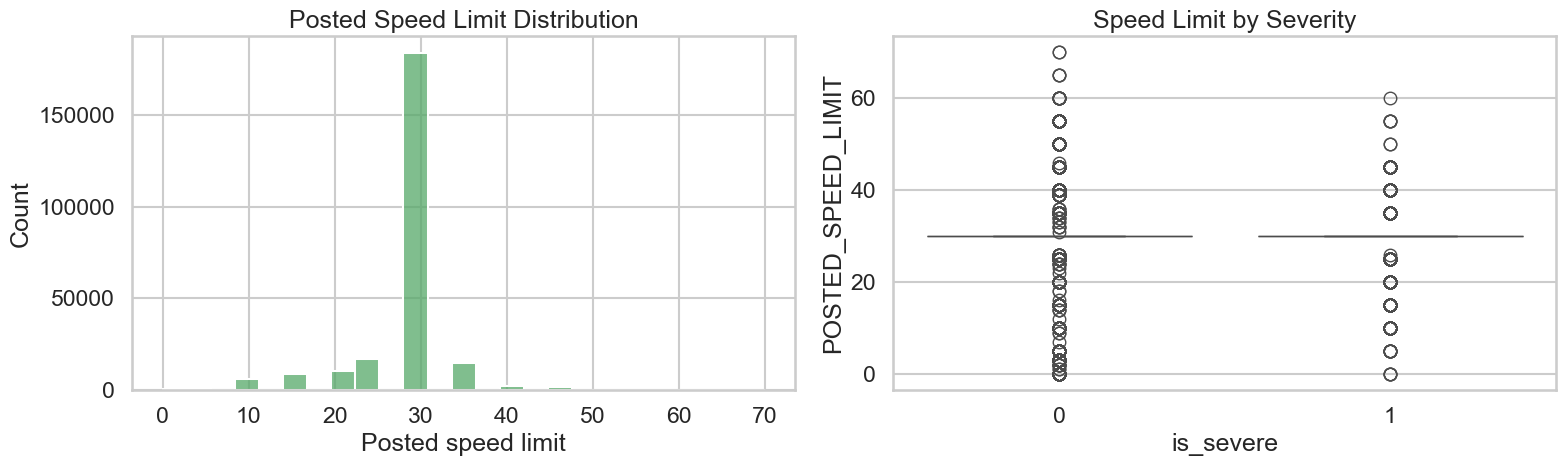

In [229]:
speed_stats = {}

if 'POSTED_SPEED_LIMIT' in train_fe.columns:
    tmp = train_fe[['POSTED_SPEED_LIMIT', 'is_severe']].copy()
    tmp['POSTED_SPEED_LIMIT'] = pd.to_numeric(tmp['POSTED_SPEED_LIMIT'], errors='coerce')
    tmp = tmp.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.histplot(tmp['POSTED_SPEED_LIMIT'], bins=25, color='#55A868', ax=axes[0])
    axes[0].set_title('Posted Speed Limit Distribution')
    axes[0].set_xlabel('Posted speed limit')

    sns.boxplot(data=tmp, x='is_severe', y='POSTED_SPEED_LIMIT', ax=axes[1], color='#4C72B0')
    axes[1].set_title('Speed Limit by Severity')
    axes[1].set_xlabel('is_severe')
    axes[1].set_xticks([0, 1], ['0', '1'])

    plt.tight_layout()
    save_fig('14_speed_distribution_and_boxplot.png')
    plt.show()

    speed_stats = {
        'median_non_severe': float(tmp.loc[tmp['is_severe'] == 0, 'POSTED_SPEED_LIMIT'].median()),
        'median_severe': float(tmp.loc[tmp['is_severe'] == 1, 'POSTED_SPEED_LIMIT'].median()),
    }


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/16_numeric_correlation_heatmap.png


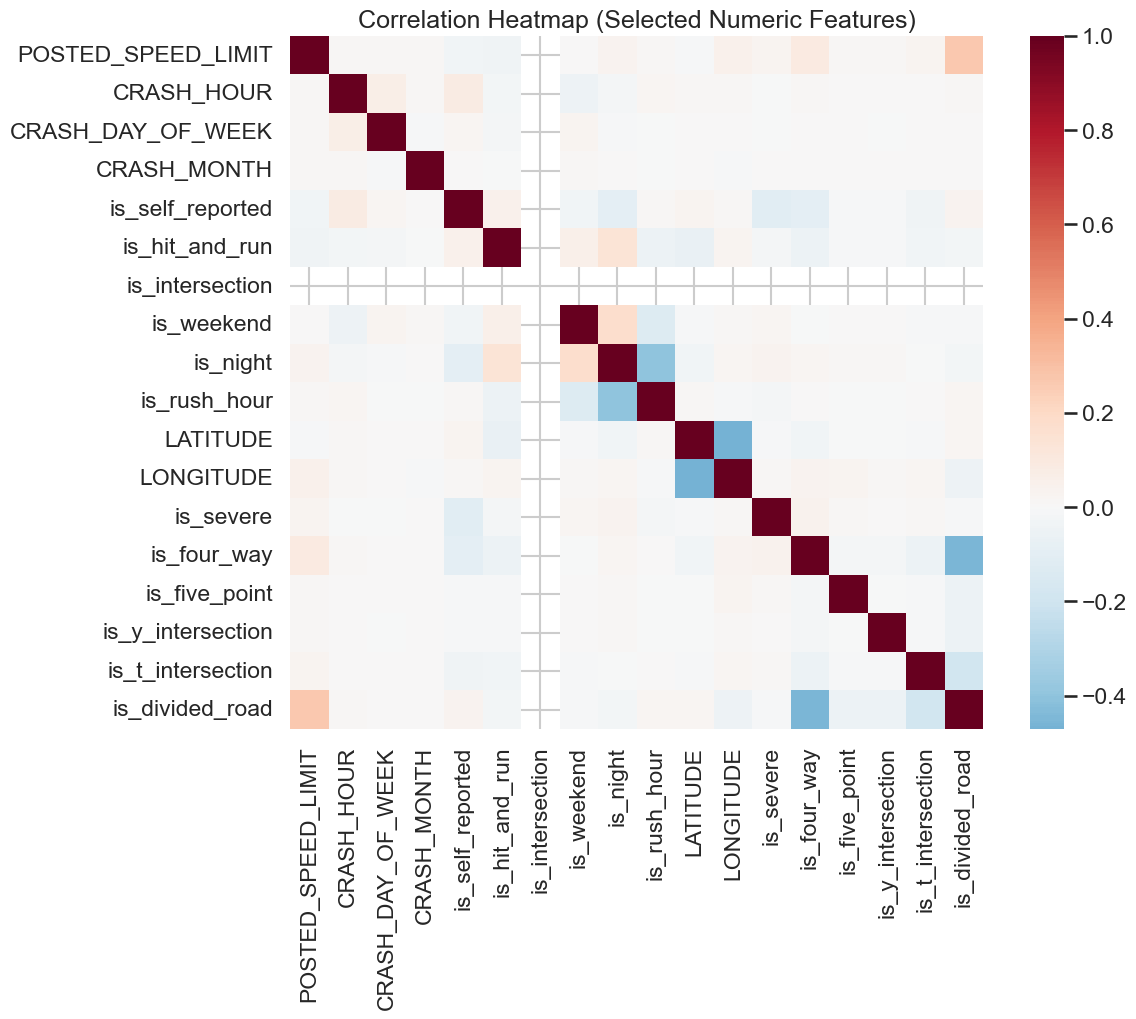

Top absolute correlations with is_severe:
is_self_reported     -0.108617
is_four_way           0.042698
is_night              0.038459
POSTED_SPEED_LIMIT    0.028905
is_rush_hour         -0.020067
is_hit_and_run       -0.018943
is_weekend            0.018055
LATITUDE             -0.014078


In [230]:
corr_candidates = [
    'POSTED_SPEED_LIMIT', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH',
    'is_self_reported', 'is_hit_and_run', 'is_intersection', 'is_weekend', 'is_night',
    'is_rush_hour', 'LATITUDE', 'LONGITUDE', 'is_severe',   'is_four_way', 'is_five_point', 'is_y_intersection', 'is_t_intersection', 'is_divided_road'
]
corr_cols = [c for c in corr_candidates if c in train_fe.columns]
corr_df = train_fe[corr_cols].copy()
for col in corr_df.columns:
    corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')

corr = corr_df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap (Selected Numeric Features)')
save_fig('16_numeric_correlation_heatmap.png')
plt.show()

if 'is_severe' in corr.columns:
    _corr_series = corr['is_severe'].drop('is_severe').dropna()
    target_corr = _corr_series.reindex(_corr_series.abs().sort_values(ascending=False).index)
    print('Top absolute correlations with is_severe:')
    print(target_corr.head(8).to_string())


## 5) Spatial analysis


Rows with valid coordinates: 246221
Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/05_spatial_scatter_sample.png


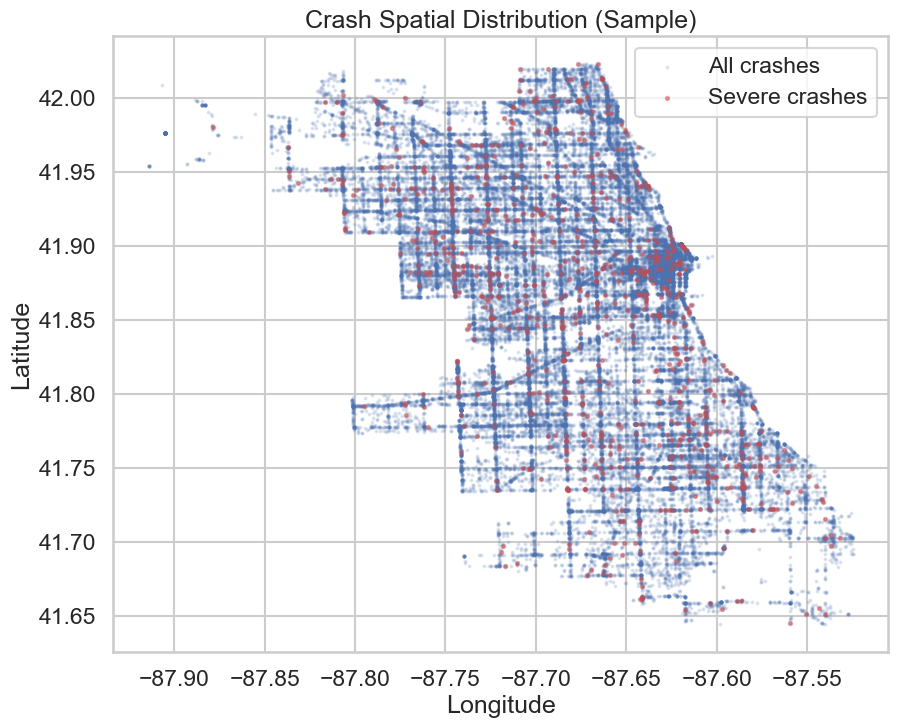

In [231]:
spatial = train_raw.dropna(subset=['LATITUDE', 'LONGITUDE']).copy()
print('Rows with valid coordinates:', len(spatial))

sample_n = min(50000, len(spatial))
spatial_sample = spatial.sample(sample_n, random_state=42)
severe_sample = spatial_sample[spatial_sample['is_severe'] == 1]

plt.figure(figsize=(10, 8))
plt.scatter(spatial_sample['LONGITUDE'], spatial_sample['LATITUDE'], s=2, alpha=0.15, label='All crashes', color='#4C72B0')
if not severe_sample.empty:
    plt.scatter(severe_sample['LONGITUDE'], severe_sample['LATITUDE'], s=6, alpha=0.45, label='Severe crashes', color='#C44E52')
plt.title('Crash Spatial Distribution (Sample)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='best')
save_fig('05_spatial_scatter_sample.png')
plt.show()


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/06_hexbin_crash_density.png


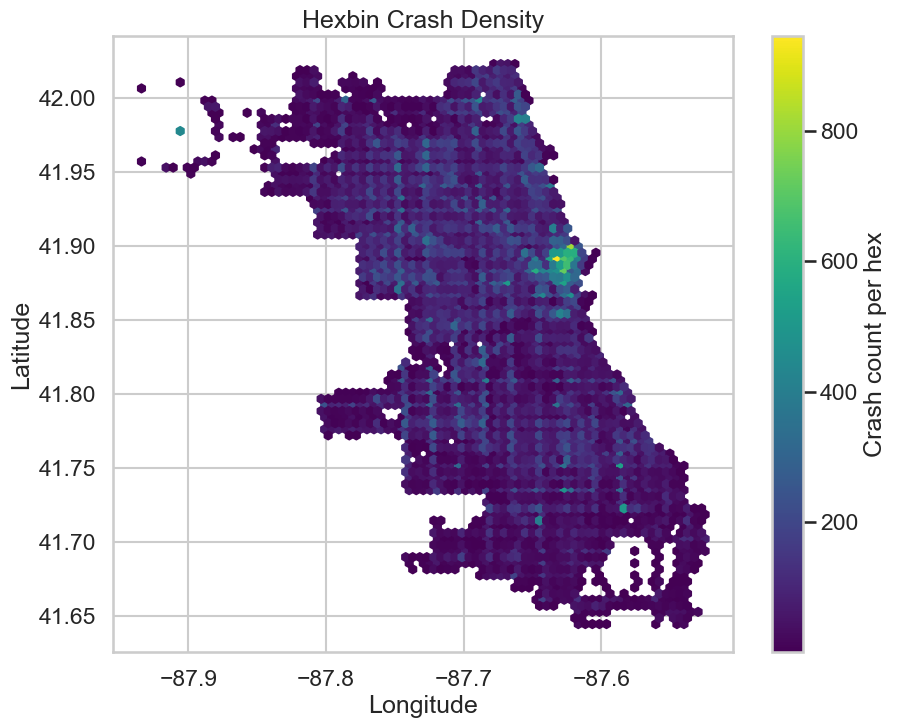

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/07_hexbin_severe_density.png


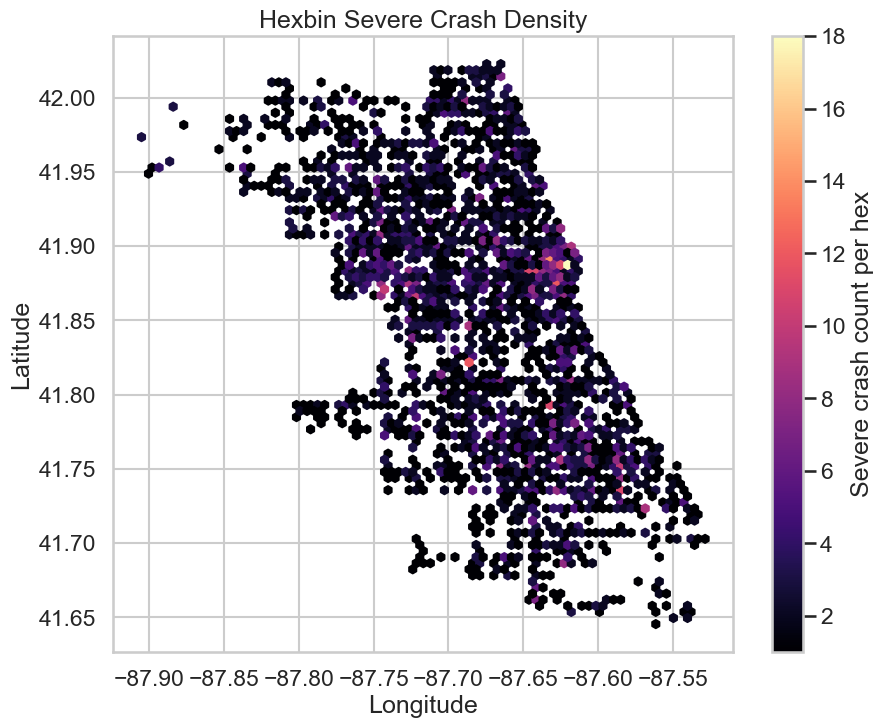

In [232]:
plt.figure(figsize=(10, 8))
plt.hexbin(spatial['LONGITUDE'], spatial['LATITUDE'], gridsize=80, cmap='viridis', mincnt=1)
plt.colorbar(label='Crash count per hex')
plt.title('Hexbin Crash Density')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
save_fig('06_hexbin_crash_density.png')
plt.show()

severe_spatial = spatial[spatial['is_severe'] == 1]
if len(severe_spatial) > 0:
    plt.figure(figsize=(10, 8))
    plt.hexbin(severe_spatial['LONGITUDE'], severe_spatial['LATITUDE'], gridsize=80, cmap='magma', mincnt=1)
    plt.colorbar(label='Severe crash count per hex')
    plt.title('Hexbin Severe Crash Density')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    save_fig('07_hexbin_severe_density.png')
    plt.show()


Top stable grid hotspots (>=20 crashes):
 lat_bin  lon_bin  crash_count  severe_count  severe_rate_pct  severe_rate_shrunk_pct
 41.7225 -87.5700           41             6        14.634146                9.146747
 41.9550 -87.8375           20             4        20.000000                8.988380
 41.9550 -87.8925           26             4        15.384615                8.025340
 41.8350 -87.6075           33             4        12.121212                7.133635
 41.7300 -87.5425           20             3        15.000000                6.988380
 41.6700 -87.6425           21             3        14.285714                6.851353
 41.7825 -87.6200           21             3        14.285714                6.851353
 41.7425 -87.6200           22             3        13.636364                6.719596
 41.8700 -87.7250           53             5         9.433962                6.619506
 41.8550 -87.6150           38             4        10.526316                6.609103
 41.7425 -87.

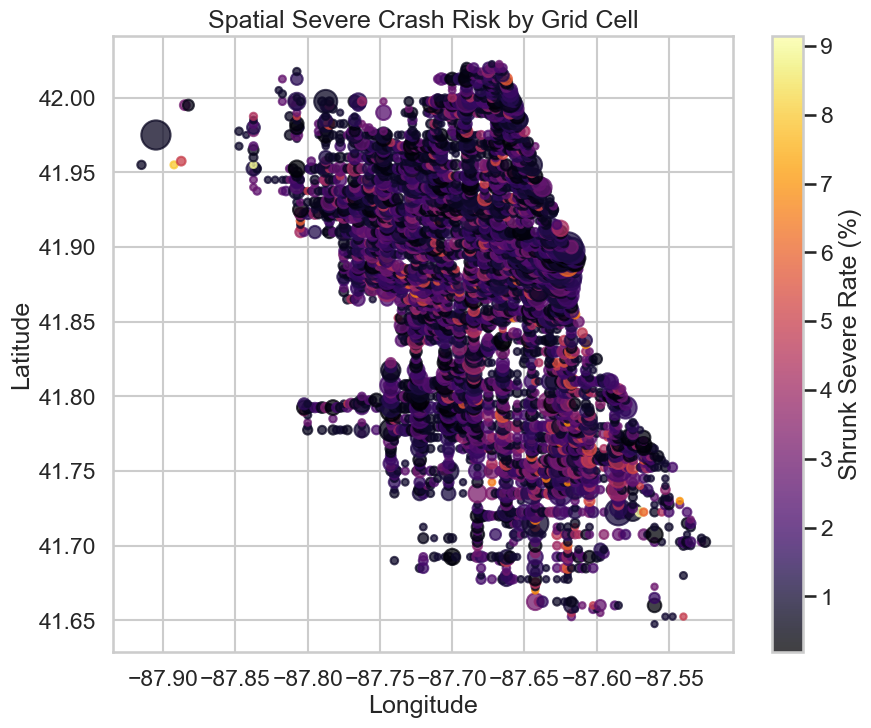

In [233]:
spatial = spatial.copy()

# 1. Create smaller spatial grid
GRID_SIZE = 0.0025   # smaller than 0.01, roughly ~500m level because latitude: 0.01 ≈ 1.1 km
#longitude in Chicago: 0.01 ≈ 0.8 kmlongitude in Chicago: 0.01 ≈ 0.8 km

spatial["lat_bin"] = (spatial["LATITUDE"] / GRID_SIZE).round() * GRID_SIZE
spatial["lon_bin"] = (spatial["LONGITUDE"] / GRID_SIZE).round() * GRID_SIZE

# 2. Aggregate becauuse severe_rate_pct can over-rank low-volume cells, misleading
grid = (
    spatial.groupby(["lat_bin", "lon_bin"], as_index=False)
    .agg(
        crash_count=("is_severe", "size"),
        severe_count=("is_severe", "sum"),
        severe_rate=("is_severe", "mean")
    ))

grid["severe_rate_pct"] = grid["severe_rate"] * 100

# 3. Keep stable cells
grid = grid[grid["crash_count"] >= 20].copy()

# 4. Shrink severe rate for stability
#    (helps avoid over-ranking small cells)
global_rate = spatial["is_severe"].mean()
alpha = 30

grid["severe_rate_shrunk"] = (grid["severe_count"] + alpha * global_rate) / (grid["crash_count"] + alpha)
grid["severe_rate_shrunk_pct"] = grid["severe_rate_shrunk"] * 100

# 5. Rank hotspots
hotspots = grid.sort_values(["severe_rate_shrunk_pct", "crash_count"],
    ascending=[False, False]).head(12)

print("Top stable grid hotspots (>=20 crashes):")
print(hotspots[
        ["lat_bin", "lon_bin", "crash_count", "severe_count",
         "severe_rate_pct", "severe_rate_shrunk_pct"]
    ].to_string(index=False))

# 6. Visualize
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    grid["lon_bin"],
    grid["lat_bin"],
    c=grid["severe_rate_shrunk_pct"],
    s=grid["crash_count"],
    cmap="inferno",
    alpha=0.75
)

plt.colorbar(scatter, label="Shrunk Severe Rate (%)")
plt.title("Spatial Severe Crash Risk by Grid Cell")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

severe_count--> tells whether a hotspot has real harm volume.
severe_rate_shrunk --> reduces instability from medium-small cells.
smaller GRID_SIZE --> This gets closer to the scale of actual interventions.
map --> to see whether hotspots cluster spatially.

Crash locations were aggregated into geographic grid cells to identify stable spatial hotspots. For each cell, we computed total crash count, severe crash count, and severe crash rate. To reduce the influence of small-sample volatility, we also estimated a shrunk severe rate that pulls low-exposure cells toward the citywide average. Cells with at least 30 crashes were treated as stable candidates for hotspot review.

## 7) Aggregation preview for condition-level risk modeling

This section makes the condition-profile view easier to interpret by separating three questions:
1. How does severe rate behave across exposure levels?
2. Which weather-lighting combinations carry higher weighted risk?
3. Which condition profiles stay high-risk after applying a stability adjustment?


In [235]:
#7) Aggregation preview for condition-level risk modeling
# Goal: summarize into location-level and condition-level profiles that preview
# which combinations of risk factors are associated with higher severe crash rates before formal modeling.

preview = train_fe.copy()

# Spatial grid
# Use a moderate grid size for interpretable hotspot previews.
GRID_SIZE = 0.005   # to approximate intersection-level clusters , nearby cells (~500 m).

preview['grid_lat'] = (pd.to_numeric(preview['LATITUDE'], errors='coerce') / GRID_SIZE).round() * GRID_SIZE
preview['grid_lon'] = (pd.to_numeric(preview['LONGITUDE'], errors='coerce') / GRID_SIZE).round() * GRID_SIZE

if 'weather_bucket' not in preview.columns:
    weather_src = preview.get('WEATHER_CONDITION', pd.Series('UNKNOWN', index=preview.index)).astype(str).str.upper()

    preview['weather_bucket'] = np.select(
        [
            weather_src.str.contains('CLEAR'),
            weather_src.str.contains('CLOUD'),
            weather_src.str.contains('RAIN|DRIZZLE'),
            weather_src.str.contains('SNOW|SLEET|ICE|FREEZING|BLOWING SNOW'),
            weather_src.str.contains('FOG|SMOKE|HAZE'),
            weather_src.eq('UNKNOWN')
        ],
        ['CLEAR', 'CLOUDY', 'RAIN', 'SNOW_ICE', 'LOW_VISIBILITY', 'UNKNOWN'],
        default='OTHER'
    )

# 7.2 Create lighting bucket consistently
if 'lighting_bucket' not in preview.columns:
    lighting_src = preview.get('LIGHTING_CONDITION', pd.Series('UNKNOWN', index=preview.index)).astype(str).str.upper()

    preview['lighting_bucket'] = np.select(
        [
            lighting_src.str.contains('DAYLIGHT'),
            lighting_src.str.contains('DARKNESS, LIGHTED'),
            lighting_src.str.contains('DARKNESS') & ~lighting_src.str.contains('LIGHTED'),
            lighting_src.str.contains('DAWN|DUSK'),
            lighting_src.eq('UNKNOWN')
        ],
        ['DAYLIGHT', 'DARK_LIT', 'DARK_UNLIT', 'DAWN_DUSK', 'UNKNOWN'],
        default='OTHER'
    )

if 'time_bucket' not in preview.columns:
    preview['time_bucket'] = np.select(
        [
            preview.get('is_weekend', 0).astype(int) == 1,
            preview.get('is_rush_hour', 0).astype(int) == 1,
            preview.get('is_night', 0).astype(int) == 1,
        ],
        ['WEEKEND', 'RUSH_HOUR', 'NIGHT'],
        default='DAYTIME'
    )

if 'speed_context' not in preview.columns:
    speed_src = pd.to_numeric(preview.get('POSTED_SPEED_LIMIT', np.nan), errors='coerce')

    preview['speed_context'] = np.select(
        [
            speed_src >= 40,
            speed_src >= 30,
            speed_src.notna()
        ],
        ['HIGH_SPEED', 'MID_SPEED', 'LOW_SPEED'],
        default='UNKNOWN'
    )

# Aggregation

agg_preview = (
    preview.dropna(subset=['grid_lat', 'grid_lon'])
           .groupby(
               [
                   'grid_lat', 'grid_lon',
                   'weather_bucket', 'lighting_bucket',
                   'time_bucket', 'speed_context'
               ],
               as_index=False
           )
           .agg(
               crash_count=('is_severe', 'size'),
               severe_count=('is_severe', 'sum'),
               severe_rate=('is_severe', 'mean'),
               avg_posted_speed=('POSTED_SPEED_LIMIT', 'mean'),
               pct_intersection=('is_intersection', 'mean') if 'is_intersection' in preview.columns else ('is_severe', 'mean'),
               pct_hit_run=('is_hit_and_run', 'mean') if 'is_hit_and_run' in preview.columns else ('is_severe', 'mean'),
               pct_self_reported=('is_self_reported', 'mean') if 'is_self_reported' in preview.columns else ('is_severe', 'mean'),
               pct_night=('is_night', 'mean') if 'is_night' in preview.columns else ('is_severe', 'mean'),
               pct_weekend=('is_weekend', 'mean') if 'is_weekend' in preview.columns else ('is_severe', 'mean'),
               pct_rush_hour=('is_rush_hour', 'mean') if 'is_rush_hour' in preview.columns else ('is_severe', 'mean'),
           )
)

agg_preview['severe_rate_pct'] = agg_preview['severe_rate'] * 100

# Empirical-Bayes shrinkage for stable ranking
global_rate = preview['is_severe'].mean()
alpha = 30

agg_preview['severe_rate_shrunk'] = (agg_preview['severe_count'] + alpha * global_rate) /(agg_preview['crash_count'] + alpha)
agg_preview['severe_rate_shrunk_pct'] = agg_preview['severe_rate_shrunk'] * 100

# Stable profiles
stable_profiles = agg_preview[agg_preview['crash_count'] >= 30].copy()

print('Total condition profiles:', len(agg_preview))
print('Stable profiles (crash_count >= 30):', len(stable_profiles))
print('Global severe rate (%):', round(global_rate * 100, 3))
print('Crash-count quantiles (stable profiles):')
print(stable_profiles['crash_count'].quantile([0.25, 0.5, 0.75, 0.9, 0.95]).to_string())

Total condition profiles: 73787
Stable profiles (crash_count >= 30): 993
Global severe rate (%): 1.647
Crash-count quantiles (stable profiles):
0.25    34.0
0.50    40.0
0.75    50.0
0.90    69.0
0.95    85.8


Empirical-Bayes shrinkage was applied to stabilize severe-rate estimates for condition profiles with limited exposure. <br>
The shrinkage parameter α controls the strength of the global prior. We set α = 30, which corresponds to approximately 30 pseudo-observations drawn from the citywide severe crash rate. This value aligns with the exposure stability diagnostic showing that severe-rate estimates become reasonably stable once crash counts exceed roughly 20–30 observations. <br>
Using α = 30 therefore balances variance reduction for sparse profiles while preserving meaningful differences among higher-exposure conditions.<br>

Total condition profiles ; 142920 means the aggregation created 142,920 different condition environments, which comes from 

grid_lat
grid_lon
weather_bucket
lighting_bucket
time_bucket
speed_context

So your 

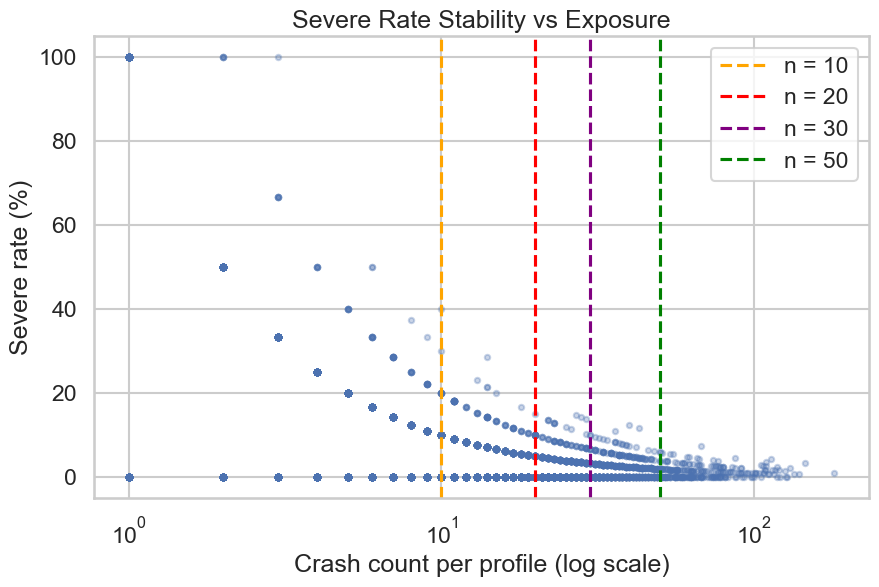

In [234]:
# Exposure stability diagnostic
plt.figure(figsize=(10,6))

plt.scatter(
    agg_preview['crash_count'],
    agg_preview['severe_rate_pct'],
    alpha=0.3,
    s=15
)

plt.xscale('log')

plt.xlabel("Crash count per profile (log scale)")
plt.ylabel("Severe rate (%)")
plt.title("Severe Rate Stability vs Exposure")

# stability reference lines
plt.axvline(10, linestyle='--', color='orange', label='n = 10')
plt.axvline(20, linestyle='--', color='red', label='n = 20')
plt.axvline(30, linestyle='--', color='purple', label='n = 30')
plt.axvline(50, linestyle='--', color='green', label='n = 50')

plt.legend()

plt.show()

The stability diagnostic shows that severe crash rate estimates fluctuate substantially for profiles with fewer than 20 observations. 
Variability decreases significantly between 20 and 30 crashes, suggesting that profiles with at least 30 crashes provide more reliable estimates. 
For exploratory condition-level analysis, a minimum exposure threshold of 30 crashes was therefore considered appropriate, while a stricter threshold of 50 crashes was used when ranking the highest-risk profiles. <BR>
it justifies for using thereshold for stable_profiles >= 30 and for rank_profiles >= 50

Number of grid cells represented: 497
Total stable profiles: 993


count    497.000000
mean       1.997988
std        1.028817
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        5.000000
Name: n_profiles, dtype: float64

Share of profiles from largest cell: 0.50%


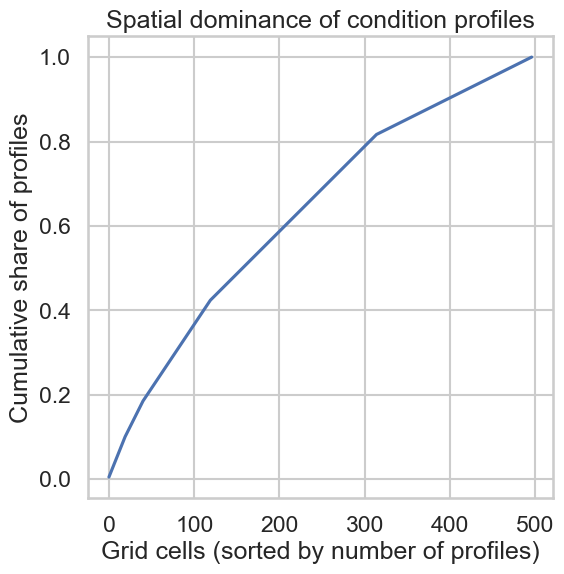

In [236]:
#Quick diagnostic that checks whether your stable profiles are dominated by only a few locations, which can silently bias clustering results:<BR>
#Are stable profiles concentrated in only a few locations?
# Count how many profiles come from each grid cell
cell_profile_counts = (
    stable_profiles
    .groupby(['grid_lat', 'grid_lon'])
    .size()
    .reset_index(name='n_profiles')
)

print("Number of grid cells represented:", len(cell_profile_counts))
print("Total stable profiles:", len(stable_profiles))

display(cell_profile_counts['n_profiles'].describe())

#Compute share of profiles from largest location
print("Share of profiles from largest cell: {:.2f}%".format(
    cell_profile_counts['n_profiles'].max() / cell_profile_counts['n_profiles'].sum() * 100
))

cell_profile_counts_sorted = cell_profile_counts.sort_values(
    'n_profiles',
    ascending=False
)

cell_profile_counts_sorted['cum_profiles'] = (
    cell_profile_counts_sorted['n_profiles'].cumsum()
)

cell_profile_counts_sorted['cum_share'] = (
    cell_profile_counts_sorted['cum_profiles'] /
    cell_profile_counts_sorted['n_profiles'].sum()
)

plt.figure(figsize=(6,6))

plt.plot(
    range(len(cell_profile_counts_sorted)),
    cell_profile_counts_sorted['cum_share']
)

plt.xlabel('Grid cells (sorted by number of profiles)')
plt.ylabel('Cumulative share of profiles')
plt.title('Spatial dominance of condition profiles')

plt.show()


0.05% shows that the top cell contributes a very small share of the profiles, indicating good spatial diversity and low risk of location bias in the profile<BR>
Stable crash condition profiles are broadly distributed across nearly 500 spatial grid cells, with each location contributing only a small number of profiles (median = 2, maximum = 5). <BR>
This indicates that the aggregated dataset is not dominated by a small number of geographic locations and therefore is suitable for condition-level clustering analysis.

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/17_aggregation_exposure_bin_trend.png


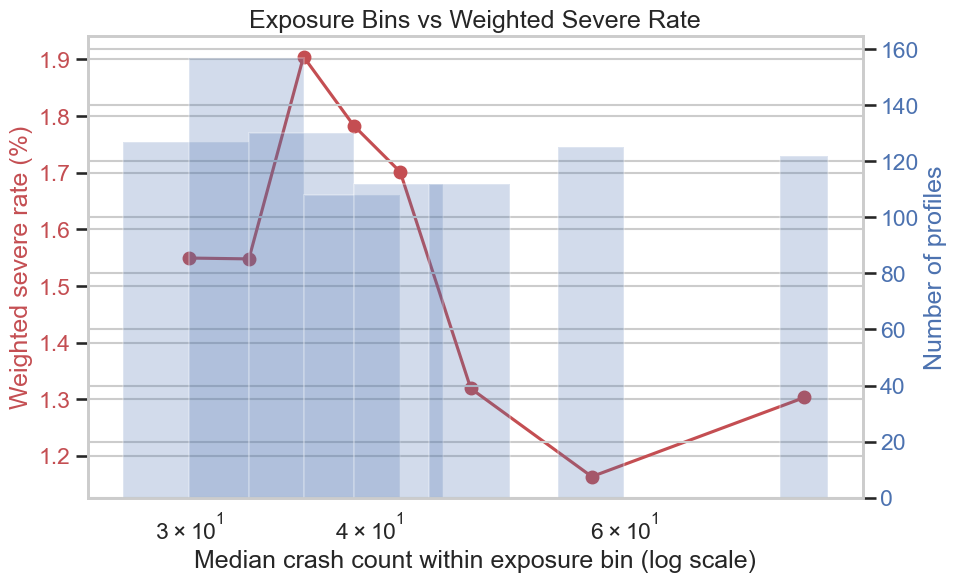

,exposure_bin,n_profiles,median_exposure,severe_count,crash_count,weighted_severe_rate_pct
0,"(29.999, 31.0]",127,30.0,60,3873,1.549187
1,"(31.0, 34.0]",157,33.0,80,5169,1.547688
2,"(34.0, 37.0]",130,36.0,89,4672,1.904966
3,"(37.0, 40.0]",108,39.0,75,4206,1.783167
4,"(40.0, 44.0]",112,42.0,81,4761,1.701323
5,"(44.0, 50.0]",112,47.0,70,5308,1.318764
6,"(50.0, 64.0]",125,57.0,83,7136,1.163117
7,"(64.0, 181.0]",122,80.0,140,10745,1.302932


In [237]:
# 7.1 Exposure-binned severe-rate trend (weighted)

exp_bin_count = min(8, stable_profiles['crash_count'].nunique())
stable_profiles['exposure_bin'] = pd.qcut(stable_profiles['crash_count'],q=exp_bin_count,duplicates='drop')

exposure_bin_stats = (
    stable_profiles.groupby('exposure_bin', as_index=False, observed=False)
                   .agg(
                       n_profiles=('crash_count', 'size'),
                       median_exposure=('crash_count', 'median'),
                       severe_count=('severe_count', 'sum'),
                       crash_count=('crash_count', 'sum'),
                   )
)

exposure_bin_stats['weighted_severe_rate_pct'] = (100 * exposure_bin_stats['severe_count'] / exposure_bin_stats['crash_count'])

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(
    exposure_bin_stats['median_exposure'],
    exposure_bin_stats['weighted_severe_rate_pct'],
    marker='o',
    color='#C44E52'
)
ax1.set_xscale('log')
ax1.set_xlabel('Median crash count within exposure bin (log scale)')
ax1.set_ylabel('Weighted severe rate (%)', color='#C44E52')
ax1.tick_params(axis='y', labelcolor='#C44E52')
ax1.set_title('Exposure Bins vs Weighted Severe Rate')

ax2 = ax1.twinx()
ax2.bar(
    exposure_bin_stats['median_exposure'],
    exposure_bin_stats['n_profiles'],
    alpha=0.25,
    color='#4C72B0',
    width=6
)
ax2.set_ylabel('Number of profiles', color='#4C72B0')
ax2.tick_params(axis='y', labelcolor='#4C72B0')

save_fig('17_aggregation_exposure_bin_trend.png')
plt.show()

display(exposure_bin_stats)

weighted_severe_rate_pct --> tells whether severe risk persists as exposure rises helps distinguish structural vs sparse risk

This chart of Exposure Bins vs Weighted Severe Rate combines three pieces of information:
X-axis : Median crash count within exposure bin (log scale). This represents how many crashes occur in each condition profile group. So each bin contains profiles with similar crash exposure. Example: 

Blue bars:  Number of profiles, which shows how many condition profiles fall into each exposure bin. 
Example: exposure bin ~31–34 crashes has 157 profile. 
Profiles are not dominated by one exposure level

Red line: Weighted severe rate (%)
Weighted severe rate =∑severe crashes divided by ∑crashes, 

Key Question: Does severe crash risk increase with exposure?
Weighted severe rate were in range of ~1.2% – 1.9%, which indicates that the more number of crash doesnt contribute to severeness of the crash.
Instead, severity appears to depend more on environmental and roadway conditions, supporting the need for condition-level risk modeling rather than relying solely on crash frequency.


Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/18_aggregation_weather_lighting_heatmap.png


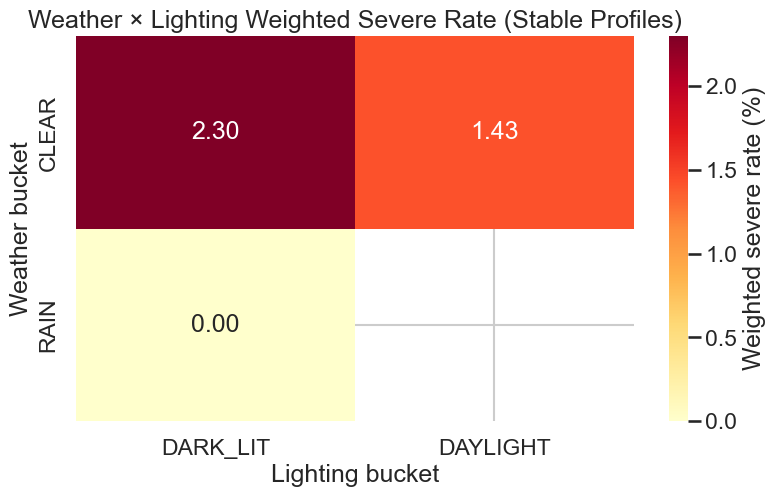

Top weather-lighting combinations (weighted severe rate):


,weather_bucket,lighting_bucket,severe_count,crash_count,n_profiles,weighted_severe_rate_pct
0,CLEAR,DARK_LIT,63,2741,62,2.298431
1,CLEAR,DAYLIGHT,615,43099,930,1.426947
2,RAIN,DARK_LIT,0,30,1,0.000000


In [238]:
# 7.2 Weather x lighting weighted severe-rate heatmap
wl = (
    stable_profiles.groupby(['weather_bucket', 'lighting_bucket'], as_index=False)
                   .agg(
                       severe_count=('severe_count', 'sum'),
                       crash_count=('crash_count', 'sum'),
                       n_profiles=('crash_count', 'size')
                   )
)

wl['weighted_severe_rate_pct'] = 100 * wl['severe_count'] / wl['crash_count']

wl_heat = wl.pivot(
    index='weather_bucket',
    columns='lighting_bucket',
    values='weighted_severe_rate_pct'
)

plt.figure(figsize=(9, 5))
sns.heatmap(
    wl_heat,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Weighted severe rate (%)'}
)
plt.title('Weather × Lighting Weighted Severe Rate (Stable Profiles)')
plt.xlabel('Lighting bucket')
plt.ylabel('Weather bucket')
save_fig('18_aggregation_weather_lighting_heatmap.png')
plt.show()

wl_rank = wl.sort_values(['weighted_severe_rate_pct', 'crash_count'],
    ascending=[False, False]
)

print('Top weather-lighting combinations (weighted severe rate):')
display(wl_rank.head(10))

This heatmap summarizes how severe crash risk changes across weather and lighting conditions using your stable condition profiles.
Interpretation of weighted_severe_rate_pct by weather × lighting: identifies risky environmental condition combinations.
This aligns with your earlier finding:

CLEAR | DARK_LIT = 2.30 was the highest-risk profiles. 
Meaning: Under clear weather at night with street lighting, about 2.30% of crashes are severe.Even with lighting, night conditions increase risk.
Possible explanation: nighttime visibility limitations; higher speeds; driver fatigue; or lower traffic enforcement

CLEAR | DAYLIGHT = 1.43%, meaning that during clear daytime conditions, severe crashes occur in about 1.43% of crashes.
This is lower than nighttime conditions, which is expected.
Explanation: Better visibility reduces severe crash risk.

RAIN | DARK_LIT = 0.00%, meaning that among the stable profiles matching this condition, no severe crashes occurred.
Meaning : This does not necessarily mean rain is safer.
Possible explanation: very small number of profiles, low crash counts in this condition, or drivers slow down during rain.

RAIN | DARK_LIT = "blank cell", which means that there were no weather × lighting profiles with ≥30 crashes for rain in daylight conditions.

Key takeawys:
This heatmap suggests that lighting conditions (day vs night) appear to influence crash severity more strongly than weather conditions in the stable profile dataset, with nighttime crashes showing higher severe crash rates than daytime crashes.

Important limitation of this figure : This heatmap is based on stable profiles only with crash_counts ≥30 crashes.
So, the heatmap reflects high-exposure environments, not all possible environments.

Saved figure: /Users/utami/CodeFolder/cmu-ml-midterm-project/image/02_eda/19_aggregation_top_condition_profiles.png


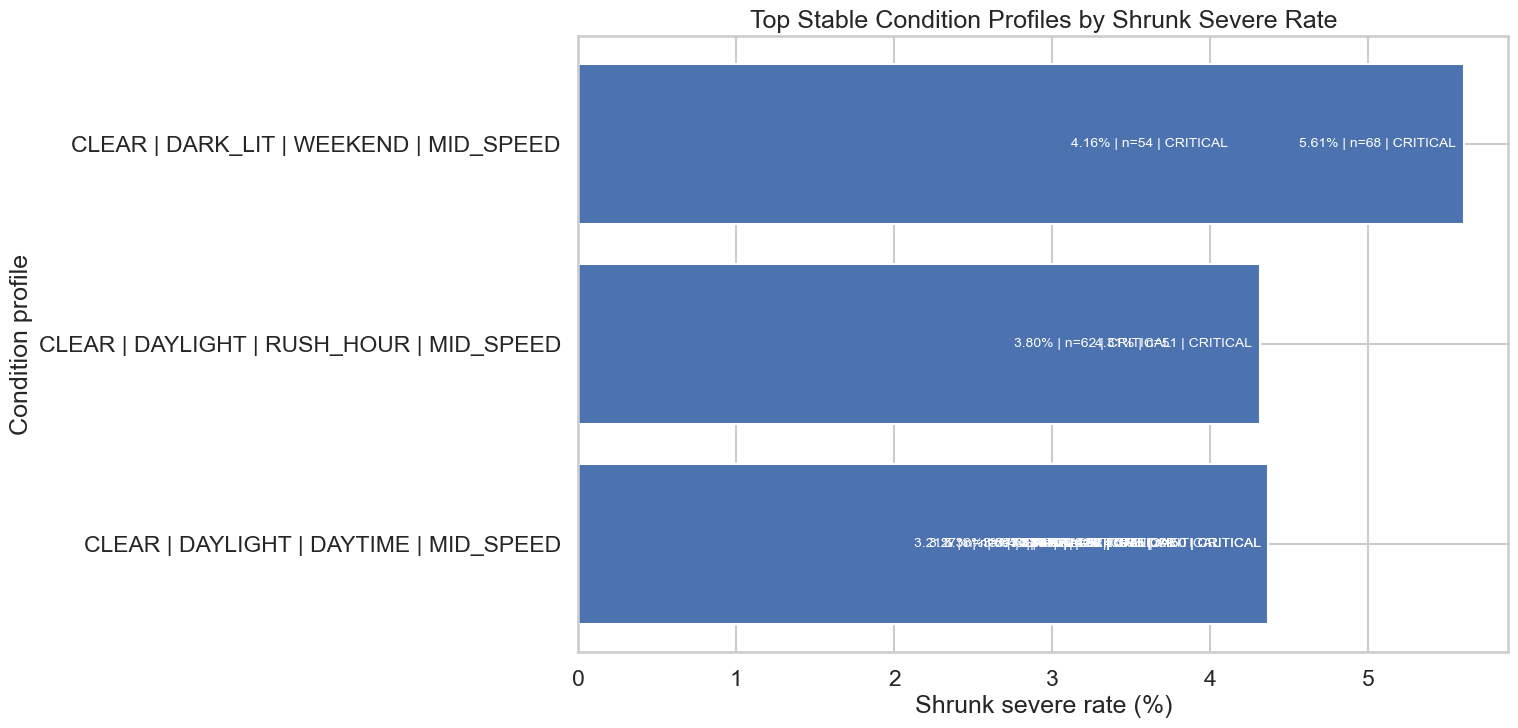

Saved priority ranking: /Users/utami/CodeFolder/cmu-ml-midterm-project/dataset/cleaned_data/aggregation_priority_profiles.csv
Saved top profiles: /Users/utami/CodeFolder/cmu-ml-midterm-project/dataset/cleaned_data/aggregation_preview_top_profiles.csv


,priority_rank,priority_tier,grid_lat,grid_lon,weather_bucket,lighting_bucket,time_bucket,speed_context,crash_count,severe_count,severe_rate_pct,severe_rate_shrunk_pct
0,1,CRITICAL,41.890,-87.635,CLEAR,DARK_LIT,WEEKEND,MID_SPEED,68,5,7.352941,5.606317
1,2,CRITICAL,41.750,-87.645,CLEAR,DAYLIGHT,DAYTIME,MID_SPEED,50,3,6.000000,4.367738
2,3,CRITICAL,41.880,-87.755,CLEAR,DAYLIGHT,DAYTIME,MID_SPEED,50,3,6.000000,4.367738
3,4,CRITICAL,41.810,-87.665,CLEAR,DAYLIGHT,RUSH_HOUR,MID_SPEED,51,3,5.882353,4.313815
4,5,CRITICAL,41.885,-87.635,CLEAR,DARK_LIT,WEEKEND,MID_SPEED,54,3,5.555556,4.159750
5,6,CRITICAL,41.845,-87.705,CLEAR,DAYLIGHT,DAYTIME,MID_SPEED,55,3,5.454545,4.110812
6,7,CRITICAL,41.870,-87.745,CLEAR,DAYLIGHT,DAYTIME,MID_SPEED,87,4,4.597701,3.841188
7,8,CRITICAL,41.770,-87.665,CLEAR,DAYLIGHT,DAYTIME,MID_SPEED,61,3,4.918033,3.839769
8,9,CRITICAL,41.895,-87.635,CLEAR,DAYLIGHT,DAYTIME,MID_SPEED,114,5,4.385965,3.815410
9,10,CRITICAL,41.765,-87.585,CLEAR,DAYLIGHT,RUSH_HOUR,MID_SPEED,62,3,4.838710,3.798033


In [246]:
# 7.3 Stable high-risk profile ranking
#using EBS method to create EBS priority ranking
rank_profiles = stable_profiles[stable_profiles['crash_count'] >= 50].copy()

# Create profile label for interpretability
rank_profiles['profile_label'] = (
    rank_profiles['weather_bucket'].astype(str) + ' | ' +
    rank_profiles['lighting_bucket'].astype(str) + ' | ' +
    rank_profiles['time_bucket'].astype(str) + ' | ' +
    rank_profiles['speed_context'].astype(str)
)

# Rank profiles using Empirical Bayes shrunk severe rate
rank_profiles = rank_profiles.sort_values(['severe_rate_shrunk_pct', 'crash_count'],ascending=[False, False]).reset_index(drop=True)

# Priority rank #each stable profile has its priority rank
rank_profiles['priority_rank'] = np.arange(1, len(rank_profiles) + 1)

# Convert rank to priority tier
def assign_priority_tier(rank):
    if rank <= 20:
        return 'CRITICAL'
    elif rank <= 100:
        return 'HIGH'
    elif rank <= 300:
        return 'MODERATE'
    else:
        return 'LOW'

rank_profiles['priority_tier'] = rank_profiles['priority_rank'].apply(assign_priority_tier)

# Show top profiles
top_profiles = rank_profiles.head(15).copy()

# Plotting dataframe
plot_df = top_profiles.sort_values('severe_rate_shrunk_pct', ascending=True)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    plot_df['profile_label'],
    plot_df['severe_rate_shrunk_pct'],
    color='#4C72B0'
)

# Add labels inside bars
for bar, n, tier in zip(
    bars,
    plot_df['crash_count'],
    plot_df['priority_tier']
):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    plt.text(
        width - 0.05,
        y,
        f'{width:.2f}% | n={int(n)} | {tier}',
        va='center',
        ha='right',
        color='white',
        fontsize=10
    )

plt.xlabel('Shrunk severe rate (%)')
plt.ylabel('Condition profile')
plt.title('Top Stable Condition Profiles by Shrunk Severe Rate')
save_fig('19_aggregation_top_condition_profiles.png')
plt.show()

# Save full priority ranking
priority_path = DATA_ROOT / 'cleaned_data' / 'aggregation_priority_profiles.csv'
rank_profiles.to_csv(priority_path, index=False)
print("Saved priority ranking:", priority_path.resolve())

# Save top profiles
top_path = DATA_ROOT / 'cleaned_data' / 'aggregation_preview_top_profiles.csv'
top_profiles.to_csv(top_path, index=False)
print('Saved top profiles:', top_path.resolve())

display(
    top_profiles[
        [
            'priority_rank',
            'priority_tier',
            'grid_lat', 'grid_lon',
            'weather_bucket', 'lighting_bucket', 'time_bucket', 'speed_context',
            'crash_count', 'severe_count',
            'severe_rate_pct', 'severe_rate_shrunk_pct'
        ]
    ]
)

The Top Stable Condition Profiles Ranking is based on Empirical Bayes Shrunk Severe Rate, which means severity risk adjusted for small sample bias.<BR>
Example: values of 5.61%, 4.37%, are are statistically stabilized severe crash probabilities.<BR>
The global rate earlier was ~1.65%, so these profiles are 2–3× higher than average.

The highest Profile: CLEAR | DARK_LIT | WEEKEND | MID_SPEED = 5.6%, which means Crashes under these conditions are much more likely to become severe<BR>
Possible possibility, such as nighttime driving, weekend recreational activity, higher speeds, alcohol or fatigue, lower traffic enforcement often produce high-energy collisions.


2nd highest profile : CLEAR | DAYLIGHT | RUSH_HOUR | MID_SPEED = 3.8%.
Meaning: Even though rush hour has lower speeds, the crash environment still produces elevated severity.
Possible causes: congestion; aggressive lane changes; rear-end chain crashes; intersection conflicts.

3rd highest profile : CLEAR | DAYLIGHT | DAYTIME | MID_SPEED = 3.2%
Meaning: This suggests the normal time conditions also still produces elevated severity.
Possible explanation: it could be road design, because Mid-speed urban arterials (30–40 mph) often have intersections, turning traffic, pedestrian crossings, or signal conflicts.<BR>

Key Findings:
MUrban mid-speed roads (30–40 mph) are a consistent severity environment despite whether it was rush hour or daytime. <BR>
Therefore, the environment matters more than the weather (weather is constant on CLEAR on those three highest profile)<BR>
This suggests roadway structure and traffic context drive severity.

Initial Hypothesis/ analysis suggests CDOT should prioritize interventions in: mid-speed arterial roads, then especially during nighttime or weekend periods.


## 8) Key takeaways for policy and modeling handoff


Summary notes:
1. Class imbalance remains strong and should be handled explicitly in modeling.
2. Temporal risk concentration appears in specific hours and day patterns, useful for deployment timing.
3. Categorical context (weather, lighting, crash type, traffic control, causes) shows meaningful risk variation.
4. Numerical signals (speed context, unit count, selected correlations) are informative but should be interpreted with effect size and exposure.
5. Spatial concentration persists in a subset of grid cells, supporting location-prioritized intervention.
6. Aggregated profile analysis improves interpretability by combining stability filters, weighted rates, and profile-level ranking.
7. EDA figures are exported to `image/02_eda/` for paper and presentation use.
